# Mental Health in Technology Jobs
## Unsupervised Learning & Feature Engineering

### 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [ ]:
# Loading a local CSV file into a DataFrame for an initial inspection of the data and the shape of the dataset

df = pd.read_csv('/Users/fessnaldo/Desktop/Case_Study_ML/data/raw/mental_health_data.csv')

print(f"Shape: {df.shape}")

df.head()

Shape: (1433, 63)


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


In [ ]:
# Displaying the full column names

for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

0: Are you self-employed?
1: How many employees does your company or organization have?
2: Is your employer primarily a tech company/organization?
3: Is your primary role within your company related to tech/IT?
4: Does your employer provide mental health benefits as part of healthcare coverage?
5: Do you know the options for mental health care available under your employer-provided coverage?
6: Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
7: Does your employer offer resources to learn more about mental health concerns and options for seeking help?
8: Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?
9: If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
10: Do you think that discussing a mental health disorder with your employer would have negative co

The dataset contains 1,433 participants and 63 features. The high dimensionality of the dataset confirms the need for dimensionality reduction techniques in later steps.

### 2. Missing Values & Data Quality

#### 2.1 Visualization of Missing Values

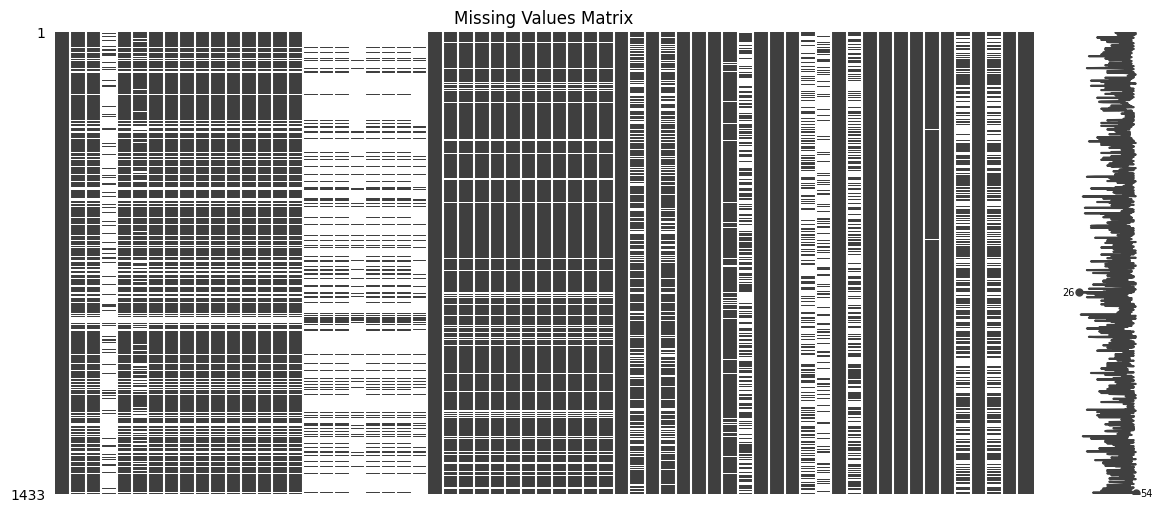

In [4]:
# Initial visualization of the missing values in the dataset

msno.matrix(df, figsize=(14, 6), fontsize=8)
plt.title('Missing Values Matrix')
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/missing_values_matrix.png', dpi=100)
plt.show()

#### 2.2 Quantitative Missing Values Analysis

In [ ]:
# Calculating and displaying the percentage of missing values per column

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct
}).sort_values('Percentage (%)', ascending=False)

cols_with_missing = missing_df[missing_df['Missing Values'] > 0]
print(f"Columns with missing values: {len(cols_with_missing)} out of {len(df.columns)}")
print()
print(cols_with_missing)

Columns with missing values: 44 out of 63

                                                    Missing Values  \
If you have revealed a mental health issue to a...            1289   
If yes, what percentage of your work time (time...            1229   
Is your primary role within your company relate...            1170   
Do you know local or online resources to seek h...            1146   
Do you have medical coverage (private insurance...            1146   
Do you believe your productivity is ever affect...            1146   
If you have revealed a mental health issue to a...            1146   
If you have been diagnosed or treated for a men...            1146   
If you have been diagnosed or treated for a men...            1146   
If maybe, what condition(s) do you believe you ...            1111   
If yes, what condition(s) have you been diagnos...             865   
Have your observations of how another individua...             776   
If so, what condition(s) were you diagnosed wit

In [6]:
# Identifying the three structural groups of missing values

group_1146 = missing_df[missing_df['Missing Values'] == 1146].index.tolist()
group_287 = missing_df[missing_df['Missing Values'] == 287].index.tolist()
group_169 = missing_df[missing_df['Missing Values'] == 169].index.tolist()

print(f"Group 1146 missing:")
for col in group_1146:
    print(f"  - {col}")

print(f"\nGroup 2 287 missing:")
for col in group_287:
    print(f"  - {col}")

print(f"\nGroup 3 169 missing:")
for col in group_169:
    print(f"  - {col}")

Group 1146 missing:
  - Do you know local or online resources to seek help for a mental health disorder?
  - Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?
  - Do you believe your productivity is ever affected by a mental health issue?
  - If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?
  - If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?
  - If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?

Group 2 287 missing:
  - How many employees does your company or organization have?
  - Do you feel that your employer takes mental health as seriously as physical health?
  - Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?
  - Would you feel comfortable discussing a me

#### 2.3 Missing Values Summary

The analysis shows that 44 out of 63 columns contain missing values. Interestingly, several columns share exactly the same number of missing values. In particular the values 287, 169 and 1146. This suggests that the missingness is not random but likely related to specific groups of participants who skipped certain question blocks. Later, these hypotheses will be investigated further in the preprocessing phase, where an appropriate imputation strategy will be determined.

### 3. Column Removal and Data Reduction

#### 3.1 Removal of freetext and geographic columns

In [ ]:
# Identifying potential free-text columns based on number of unique values

unique_counts = df.select_dtypes(include='object').nunique().sort_values(ascending=False)
print(unique_counts)

Why or why not?                                                                                                                                                                     1085
Why or why not?.1                                                                                                                                                                   1080
Which of the following best describes your work position?                                                                                                                            264
If yes, what condition(s) have you been diagnosed with?                                                                                                                              128
If so, what condition(s) were you diagnosed with?                                                                                                                                    116
If maybe, what condition(s) do you believe you have?                       

In [ ]:
# Comparing columns with high unique values against missing value counts

high_unique_counts = unique_counts[unique_counts > 6].index.tolist()

print("Columns with more than 6 unique values and their missing value count:")
print()

# Creating a summary dataframe for better overview

summary = pd.DataFrame({
    'Unique Values': unique_counts[high_unique_counts],
    'Missing Values': [missing_df.loc[col, 'Missing Values'] if col in missing_df.index else 0 for col in high_unique_counts],
    'Missing (%)': [missing_df.loc[col, 'Percentage (%)'] if col in missing_df.index else 0.0 for col in high_unique_counts]
}).sort_values('Unique Values', ascending=False)

print(summary)

Columns with more than 6 unique values and their missing value count:

                                                    Unique Values  \
Why or why not?                                              1085   
Why or why not?.1                                            1080   
Which of the following best describes your work...            264   
If yes, what condition(s) have you been diagnos...            128   
If so, what condition(s) were you diagnosed with?             116   
If maybe, what condition(s) do you believe you ...             99   
What is your gender?                                           70   
What country do you work in?                                   53   
What country do you live in?                                   53   
What US state or territory do you work in?                     48   
What US state or territory do you live in?                     47   

                                                    Missing Values  \
Why or why not?               

In [ ]:
# Verifying the free-text nature of the identified columns by inspecting their actual responses

freetext_columns = [
    'Why or why not?',
    'Why or why not?.1',
    'If yes, what condition(s) have you been diagnosed with?',
    'If maybe, what condition(s) do you believe you have?',
    'If so, what condition(s) were you diagnosed with?'
]

# Displaying value counts to confirm unstructured and highly diverse response patterns

for col in freetext_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Why or why not? ---
Why or why not?
Not relevant                                                                                                3
I don't know                                                                                                3
Fear of discrimination                                                                                      3
None of their business.                                                                                     2
bias                                                                                                        2
                                                                                                           ..
because it is important to do the job                                                                       1
The employers reaction would tell a lot of the type of company I'd be joining.                              1
If it was relevant to the job, then yes.                                       

In [ ]:
# Define columns to remove based on prior inspection and relevance assessment

columns_to_drop = [
    
    # Free text columns containing unstructured and highly diverse responses
    
    'Why or why not?',
    'Why or why not?.1',
    'If yes, what condition(s) have you been diagnosed with?',
    'If maybe, what condition(s) do you believe you have?',
    'If so, what condition(s) were you diagnosed with?',
    
    # Columns with limited relevance
    
    'What country do you live in?',
    'What country do you work in?',
    'What US state or territory do you live in?',
    'What US state or territory do you work in?'
]

# Removing selected columns from dataset

df_clean = df.drop(columns=columns_to_drop)

# Comparing dataset dimensions before and after the column removal

print(f"Before: {df.shape}")
print(f"After: {df_clean.shape}")

Before: (1433, 63)
After: (1433, 54)


The unique value analysis identified 11 columns that needed closer inspection. The two "Why or why not?" columns were removed as they contain open-ended responses that cannot be encoded for clustering. The three condition-related columns were also dropped as they not only have very high missing rates (50–78%) but also too many unique combinations to be useful. The country and US state columns were removed as they are not relevant for the HR analysis. Gender and work position were kept as they can be standardized into meaningful categories. In total, 9 columns were dropped in this step.

#### 3.2 Updated missing values analysis

In [ ]:
# Analysing updated missing values after initial column removal
# This step is necessary to identify remaining data quality issues and to decide whether further preprocessing is required

missing = df_clean.isnull().sum()

# Calculating the percentage of missing values for each column

missing_pct = (missing / len(df_clean) * 100).round(2)

# Combining absolute and relative missing values into one overview table

missing_df_clean = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct
}).sort_values('Percentage (%)', ascending=False)

# Displaying only columns that still contain missing values

print(missing_df_clean[missing_df_clean['Missing Values'] > 0])

                                                    Missing Values  \
If you have revealed a mental health issue to a...            1289   
If yes, what percentage of your work time (time...            1229   
Is your primary role within your company relate...            1170   
Do you believe your productivity is ever affect...            1146   
If you have revealed a mental health issue to a...            1146   
If you have been diagnosed or treated for a men...            1146   
If you have been diagnosed or treated for a men...            1146   
Do you know local or online resources to seek h...            1146   
Do you have medical coverage (private insurance...            1146   
Have your observations of how another individua...             776   
Do you know the options for mental health care ...             420   
Do you feel that your employer takes mental hea...             287   
How many employees does your company or organiz...             287   
Have you heard of or

This updated analysis reveals that 9 columns exceed 55% missing values, with 6 of them sharing exactly 79.97%, corresponding to the previously identified 1146 block of diagnosis-related questions. This confirms that these columns were only answered by the minority of participants who indicated having a mental health condition, making them unsuitable for a clustering analysis that aims to represent the full workforce.

In [ ]:
# Inspecting a column individually to decide whether to put a 50% or 55% threshold for further column removal

df_clean['Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?'].value_counts()

Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?
Yes      246
No       234
Maybe    177
Name: count, dtype: int64

After the initial column removal, the updated missing value analysis shows that 10 columns still exceed 50% missing values. Interestingly, 6 of them share exactly 79.97% missing, which corresponds to the diagnosis-related block identified earlier. This confirms that these questions were only answered by participants who indicated having a mental health condition.

Before setting the threshold, the column 'Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?' was inspected individually. With 54.15% missing values it would have been removed at a 50% threshold, but given its direct relevance to workplace stigma it was decided to raise the threshold to 55% to retain it.

#### 3.3 Removal of columns exceeding threshold

In [ ]:
# Removing columns with more than 55% missing values

threshold = 0.55

# Identifying columns that exceed the missing value threshold

columns_high_missing = missing_df_clean[missing_df_clean['Percentage (%)'] > threshold * 100].index.tolist()

print(f"Columns to remove: {len(columns_high_missing)}")
print(f"\n{columns_high_missing}")

# Dropping columns with excessive missing values

df_clean = df_clean.drop(columns=columns_high_missing)

# Comparing demensions before and after cleaning

print(f"\nBefore: 53 columns")
print(f"After: {df_clean.shape[1]} columns")

Columns to remove: 9

['If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?', 'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?', 'Is your primary role within your company related to tech/IT?', 'Do you believe your productivity is ever affected by a mental health issue?', 'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?', 'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?', 'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?', 'Do you know local or online resources to seek help for a mental health disorder?', 'Do you have medical coverage (private insurance or state-provided) which includes treatment of \xa0mental health 

The column removal was conducted in two steps. First, free-text columns that cannot be meaningfully encoded, geographic columns without relevance to the HR analysis, and condition-related columns with both excessive missing values and high response variability were removed.

After this initial removal, the updated missing value analysis showed that 9 further columns still exceeded 55% missing values. Six of them share exactly 79.97% missing, which corresponds to the previously identified diagnosis-related block. This suggests that these questions were only shown to participants who indicated having a mental health condition. Although these columns could provide interesting insights, including them would bias the clustering towards a small subgroup of participants.

Therefore, the threshold was set to 55% rather than 50% after individually inspecting the column capturing the stigma effect in the workplace. With 54.15% missing values, this column would have been incorrectly removed at a lower threshold despite being directly relevant to the HR analysis.

After both removal steps, the dataset was reduced from 63 to 45 columns.

### 4. Analysis of remaining columns
#### 4.1 Remaining object columns

##### 4.1.1 Gender analysis

In [ ]:
# Overview of all unique gender values

print(f"Unique values: {df_clean['What is your gender?'].nunique()}")
print(f"\nValue counts:\n")
for val in df_clean['What is your gender?'].value_counts().index:
    print(f"'{val}': {df_clean['What is your gender?'].value_counts()[val]}")

Unique values: 70

Value counts:

'Male': 610
'male': 249
'Female': 153
'female': 95
'M': 86
'm': 79
'F': 38
'f': 23
'Male ': 11
'Female ': 9
'woman': 4
'non-binary': 4
'Woman': 3
'man': 3
'female ': 3
'Man': 2
'Agender': 2
'Nonbinary': 2
'male ': 2
'Male (cis)': 2
'human': 1
'I'm a man why didn't you make this a drop down question. You should of asked sex? And I would of answered yes please. Seriously how much text can this take? ': 1
'Fluid': 1
'mail': 1
'M|': 1
'Dude': 1
'Male/genderqueer': 1
'fem': 1
'Male (trans, FtM)': 1
'Female (props for making this a freeform field, though)': 1
' Female': 1
'Unicorn': 1
'Cis Male': 1
'mtf': 1
'Cis-woman': 1
'Genderqueer': 1
'cisdude': 1
'Genderflux demi-girl': 1
'female-bodied; no feelings about gender': 1
'cis man': 1
'AFAB': 1
'Transgender woman': 1
'Queer': 1
'none of your business': 1
'genderqueer woman': 1
'Malr': 1
'I identify as female.': 1
'Bigender': 1
'Female assigned at birth ': 1
'fm': 1
'Cis female ': 1
'Transitioned, M2F': 1
'Gen

The gender column was identified during the unique value analysis as requiring further inspection due to its 70 unique spellings. Standardization will therefore be necessary before encoding.

##### 4.1.2 Workposition analysis

In [ ]:
# Overview of work position values

print(f"Unique values: {df_clean['Which of the following best describes your work position?'].nunique()}")
print(f"\nValue counts:\n")
for val in df_clean['Which of the following best describes your work position?'].value_counts().index:
    print(f"'{val}': {df_clean['Which of the following best describes your work position?'].value_counts()[val]}")

Unique values: 264

Value counts:

'Back-end Developer': 263
'Front-end Developer': 125
'Other': 112
'Supervisor/Team Lead': 68
'Back-end Developer|Front-end Developer': 61
'DevOps/SysAdmin': 54
'One-person shop': 50
'Executive Leadership': 46
'Front-end Developer|Back-end Developer': 40
'Support': 34
'Dev Evangelist/Advocate': 28
'Designer': 28
'Supervisor/Team Lead|Back-end Developer': 19
'Front-end Developer|Designer': 18
'DevOps/SysAdmin|Back-end Developer|Front-end Developer': 17
'Back-end Developer|DevOps/SysAdmin': 16
'DevOps/SysAdmin|Back-end Developer': 15
'Supervisor/Team Lead|Back-end Developer|Front-end Developer': 15
'Front-end Developer|Back-end Developer|DevOps/SysAdmin': 12
'Supervisor/Team Lead|DevOps/SysAdmin|Back-end Developer': 9
'DevOps/SysAdmin|Support|Back-end Developer|Front-end Developer': 8
'Supervisor/Team Lead|DevOps/SysAdmin|Back-end Developer|Front-end Developer': 8
'Back-end Developer|One-person shop': 7
'Supervisor/Team Lead|Front-end Developer': 6
'Supp

Similarly, the work position column was flagged during the unique value analysis with 264 unique combinations. This is largely due to participants selecting multiple roles separated by a pipe character. To make this column usable for clustering, a standardization strategy will also be necessary.

#### 4.2 Inspection of non-object columns

In [ ]:
# Overview of remaining columns with data types

for i, col in enumerate(df_clean.columns):
    print(f"{i}: {col} — {df_clean[col].dtype}")

0: Are you self-employed? — int64
1: How many employees does your company or organization have? — object
2: Is your employer primarily a tech company/organization? — float64
3: Does your employer provide mental health benefits as part of healthcare coverage? — object
4: Do you know the options for mental health care available under your employer-provided coverage? — object
5: Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)? — object
6: Does your employer offer resources to learn more about mental health concerns and options for seeking help? — object
7: Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer? — object
8: If a mental health issue prompted you to request a medical leave from work, asking for that leave would be: — object
9: Do you think that discussing a mental health disorder with your employer would 

In [ ]:
# Identifying non-object columns for closer inspection

for i, col in enumerate(df_clean.columns):
    if df_clean[col].dtype != 'object':
        print(f"{i}: {col} — {df_clean[col].dtype}")

0: Are you self-employed? — int64
2: Is your employer primarily a tech company/organization? — float64
15: Do you have previous employers? — int64
38: Have you ever sought treatment for a mental health issue from a mental health professional? — int64
41: What is your age? — int64


In [ ]:
# Inspecting non-object columns to understand their current encoding

for col in df_clean.select_dtypes(exclude='object').columns:
    print(df_clean[col].value_counts().sort_index())
    print("\n")

Are you self-employed?
0    1146
1     287
Name: count, dtype: int64


Is your employer primarily a tech company/organization?
0.0    263
1.0    883
Name: count, dtype: int64


Do you have previous employers?
0     169
1    1264
Name: count, dtype: int64


Have you ever sought treatment for a mental health issue from a mental health professional?
0    594
1    839
Name: count, dtype: int64


What is your age?
3       1
15      1
17      1
19      4
20      6
21     15
22     32
23     24
24     42
25     44
26     64
27     63
28     74
29     79
30     94
31     82
32     72
33     69
34     69
35     74
36     50
37     59
38     54
39     55
40     36
41     24
42     29
43     30
44     31
45     27
46     22
47     14
48      9
49     13
50      9
51      7
52      7
53      3
54      7
55     12
56      5
57      4
58      1
59      2
61      2
62      1
63      4
65      1
66      1
70      1
74      1
99      1
323     1
Name: count, dtype: int64




The inspection reveals that 'Are you self-employed?', 'Do you have previous employers?' and 'Have you ever sought treatment?' are already binary encoded with 0 and 1, which explains their int64 dtype. However, it is not yet clear whether 0 corresponds to 'No' and 1 to 'Yes'. 'Is your employer primarily a tech company/organization?' shows the same binary structure but as float64.

The age column contains obvious outliers which are not plausible ages for working participants.

Therefore these five columns will be examined more closely in the next step.

##### 4.2.1 Binary column validation & age outlier detection

In [ ]:
# Cross-validation to verify binary encoding for column 'Are you self-employed?'

pd.crosstab(
    df_clean['Are you self-employed?'], 
    df_clean['How many employees does your company or organization have?'],
    dropna=False
)

How many employees does your company or organization have?,1-5,100-500,26-100,500-1000,6-25,More than 1000,NaN
Are you self-employed?,,,,,,,
0,60,248,292,80,210,256,0
1,0,0,0,0,0,0,287


In [ ]:
# Cross-validation to verify binary encoding for column 'Do you have previous employers?'

pd.crosstab(
    df_clean['Do you have previous employers?'],
    df_clean['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'],
    dropna=False
)

Did your previous employers provide resources to learn more about mental health issues and how to seek help?,None did,Some did,"Yes, they all did",NaN
Do you have previous employers?,,,,
0,0,0,0,169
1,842,371,51,0


In [ ]:
# Cross-validation to verify binary encoding for column 'Have you ever sought treatment for a mental health issue from a mental health professional?'

pd.crosstab(
    df_clean['Have you ever sought treatment for a mental health issue from a mental health professional?'],
    df_clean['Have you been diagnosed with a mental health condition by a medical professional?'],
    dropna=False
)

Have you been diagnosed with a mental health condition by a medical professional?,No,Yes
Have you ever sought treatment for a mental health issue from a mental health professional?,,
0,554,40
1,163,676


In [ ]:
# Cross-validation to verify binary encoding for column 'Is your employer primarily a tech company/organization?

pd.crosstab(
    df_clean['Is your employer primarily a tech company/organization?'],
    df['Is your primary role within your company related to tech/IT?'],
    dropna=False
)

Is your primary role within your company related to tech/IT?,0.0,1.0,NaN
Is your employer primarily a tech company/organization?,,,
0.0,15,248,0
1.0,0,0,883
NaN,0,0,287


In [ ]:
# Descriptive statistics for age column to identify outliers

df_clean['What is your age?'].describe()

count    1433.000000
mean       34.286113
std        11.290931
min         3.000000
25%        28.000000
50%        33.000000
75%        39.000000
max       323.000000
Name: What is your age?, dtype: float64

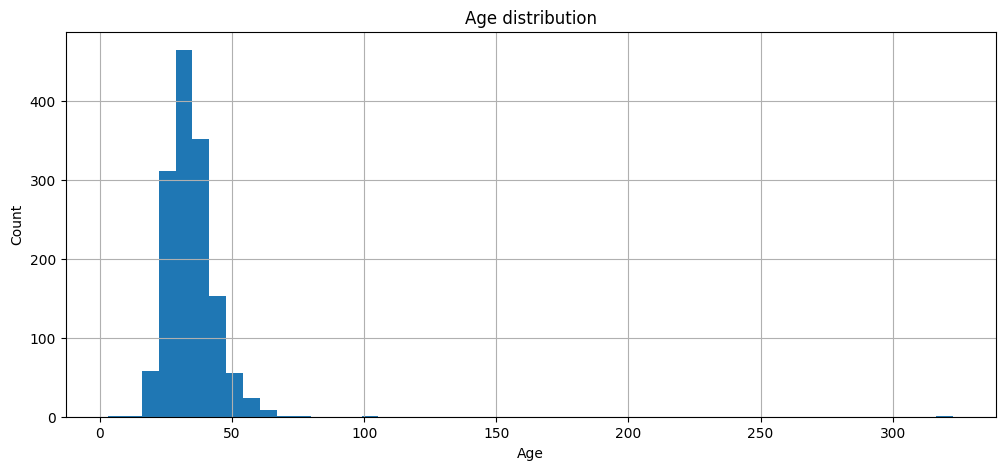

In [ ]:
# Visualization of age distribution to make outliers visible

plt.figure(figsize=(12, 5))
df_clean['What is your age?'].hist(bins=50)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/age_distribution.png', dpi=100)
plt.show()

In [ ]:
# Setting age thresholds based on realistic working age range

age_min = 18
age_max = 67

# Show values outside thresholds

outliers = df_clean[
    (df_clean['What is your age?'] < age_min) | 
    (df_clean['What is your age?'] > age_max)
]['What is your age?'].value_counts()

print(f"Outliers found: {outliers.sum()} values")
print(outliers)

Outliers found: 7 values
What is your age?
17     1
99     1
323    1
3      1
15     1
74     1
70     1
Name: count, dtype: int64


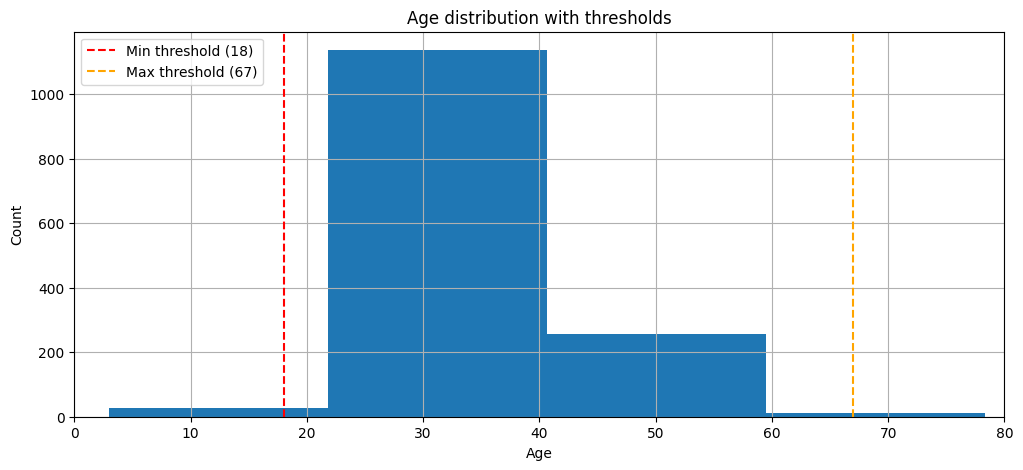

In [ ]:
# Visualization of age distribution with threshold lines

plt.figure(figsize=(12, 5))
df_clean['What is your age?'].hist(bins=17)
plt.title('Age distribution with thresholds')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xlim(0, 80)
plt.axvline(x=age_min, color='red', linestyle='--', label=f'Min threshold ({age_min})')
plt.axvline(x=age_max, color='orange', linestyle='--', label=f'Max threshold ({age_max})')
plt.legend()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/age_distribution_thresholds.png', dpi=100)
plt.show()

The cross-validation of the four non-object columns confirms that 0 corresponds to 'No' and 1 to 'Yes' in all binary columns. For 'Are you self-employed?' and 'Do you have previous employers?', this is consistent with the structural missing value patterns 
identified earlier as 287 self-employed participants and 169 participants without previous employers show NaN in the corresponding question blocks. For 'Have you ever sought treatment?', the crosstab shows a strong alignment with the diagnosis column, 
further confirming that 0 = 'No' and 1 = 'Yes'. 'Is your employer primarily a tech company/organization?' follows the same binary structure with 0.0 = 'No' and 1.0 = 'Yes'.

The age column contains 7 implausible values ranging from a minimum of 3 to a maximum of 323. Therefore, thresholds were set at 18 and 67, reflecting the minimum working age and the retirement age.

#### 4.3 Key distributions with exploratory visualizations

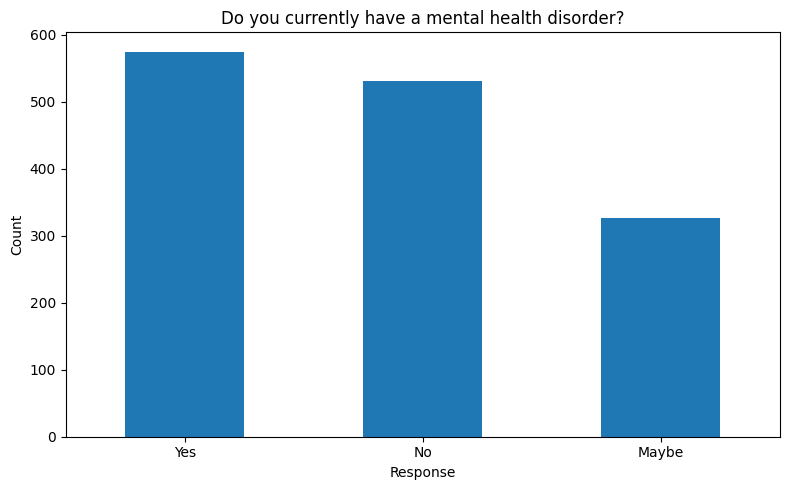

In [ ]:
# Distribution of current mental health disorders among survey participants as a key metric for the case study

plt.figure(figsize=(8, 5))
df_clean['Do you currently have a mental health disorder?'].value_counts().plot(kind='bar')
plt.title('Do you currently have a mental health disorder?')
plt.xlabel('Response')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/current_mental_health_disorder.png', dpi=100)
plt.show()

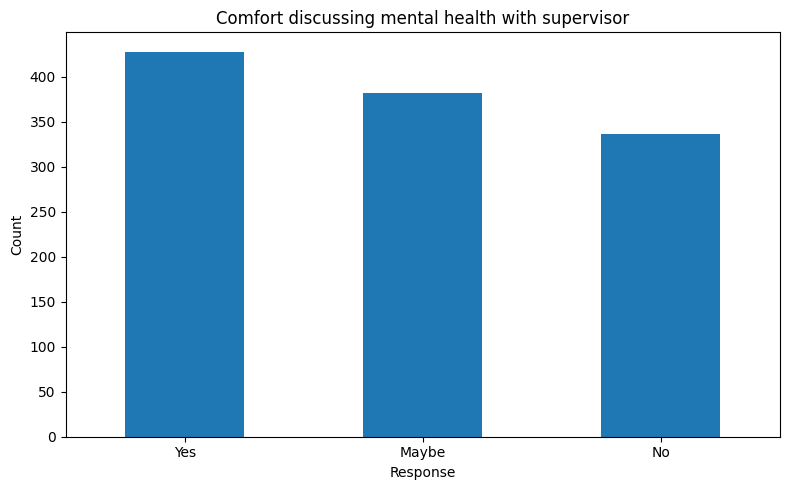

In [ ]:
# Distribution of comfort level discussing mental health with supervisor among survey participants as a key metric for the case study

plt.figure(figsize=(8, 5))
df_clean['Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?'].value_counts().plot(kind='bar')
plt.title('Comfort discussing mental health with supervisor')
plt.xlabel('Response')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/comfort_discussing_supervisor.png', dpi=100)
plt.show()

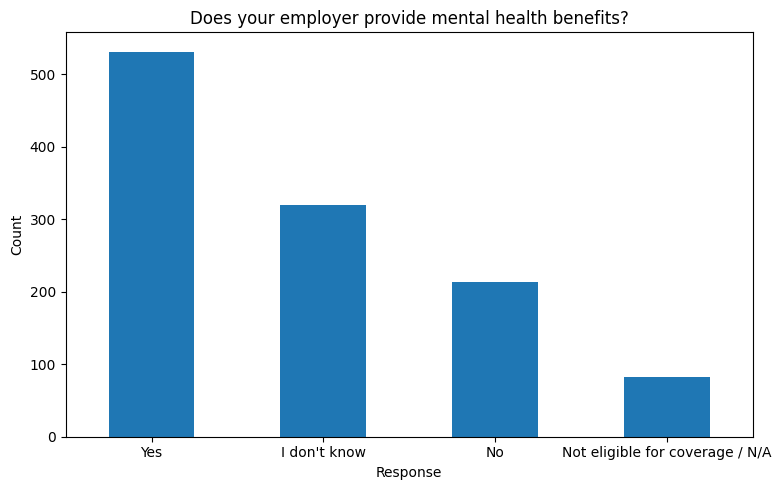

In [ ]:
# Distribution of the current state of organizational support as a key metric for the case study

plt.figure(figsize=(8, 5))
df_clean['Does your employer provide mental health benefits as part of healthcare coverage?'].value_counts().plot(kind='bar')
plt.title('Does your employer provide mental health benefits?')
plt.xlabel('Response')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/employer_mental_health_benefits.png', dpi=100)
plt.show()

In [ ]:
# Gap analysis of diagnosed and self-reported mental health disorders

pd.crosstab(
    df_clean['Do you currently have a mental health disorder?'],
    df_clean['Have you been diagnosed with a mental health condition by a medical professional?']
)

Have you been diagnosed with a mental health condition by a medical professional?,No,Yes
Do you currently have a mental health disorder?,,
Maybe,203,124
No,450,81
Yes,64,511


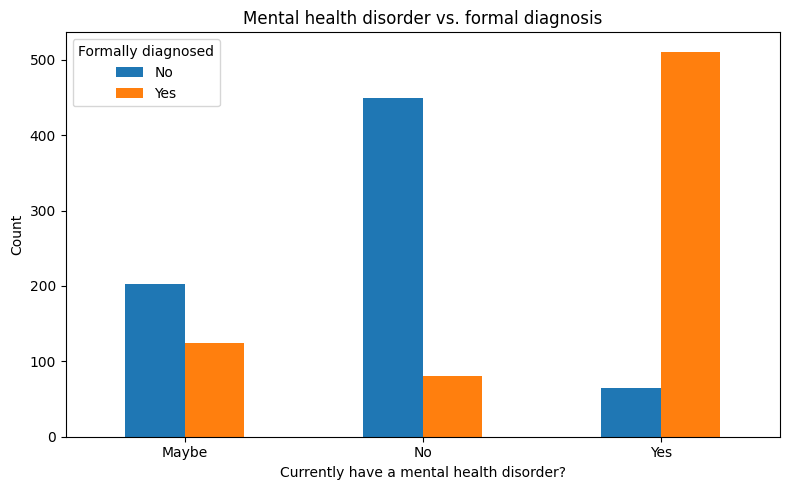

In [ ]:
# Visualization of the crosstab to better understand the relationship between self-reported mental health disorders and formal diagnoses

ct = pd.crosstab(
    df_clean['Do you currently have a mental health disorder?'],
    df_clean['Have you been diagnosed with a mental health condition by a medical professional?']
)

ct.plot(kind='bar', figsize=(8, 5))
plt.title('Mental health disorder vs. formal diagnosis')
plt.xlabel('Currently have a mental health disorder?')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Formally diagnosed')
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/disorder_vs_diagnosis.png', dpi=100)
plt.show()

The visualizations reveal three key findings relevant to the HR analysis. First, the majority of participants either currently have a mental health disorder or are unsure. Second, only a minority feels comfortable discussing mental health with their direct supervisor, indicating a significant stigma problem. Third, a notable share of participants is unaware of available employer benefits.
Finally, the crosstab shows a gap between self-reported disorders and formal diagnoses, suggesting that many affected employees have not yet sought professional help.

#### 4.4 Column answer structure inspection

Having explored the key distributions, all remaining columns are now inspected systematically to understand their answer structures before defining the encoding strategy in the preprocessing phase.

In [ ]:
# Overview of all unique answers per column

for i, col in enumerate(df_clean.columns):
    print(f"\n{i}: {col}")
    print(df_clean[col].value_counts())


0: Are you self-employed?
Are you self-employed?
0    1146
1     287
Name: count, dtype: int64

1: How many employees does your company or organization have?
How many employees does your company or organization have?
26-100            292
More than 1000    256
100-500           248
6-25              210
500-1000           80
1-5                60
Name: count, dtype: int64

2: Is your employer primarily a tech company/organization?
Is your employer primarily a tech company/organization?
1.0    883
0.0    263
Name: count, dtype: int64

3: Does your employer provide mental health benefits as part of healthcare coverage?
Does your employer provide mental health benefits as part of healthcare coverage?
Yes                                531
I don't know                       319
No                                 213
Not eligible for coverage / N/A     83
Name: count, dtype: int64

4: Do you know the options for mental health care available under your employer-provided coverage?
Do you kno

The inspection confirms that the remaining columns require different encoding strategies. Several columns follow a simple Yes/No or Yes/Maybe/No structure, while others use custom ordinal scales with more specific response options.
The gender column and the work position require standardization before encoding, while the age column requiers outlier treatment.
These findings will directly inform the encoding strategy in the preprocessing phase.

#### 4.5 EDA Summary

The exploratory data analysis covered the following steps:

After the dataset was loaded and an initial overview was established, an initial missing value analysis identified three structural groups of 1146, 287 and 169 missing values. 
Following this, freetext, geographic and high-missing columns were removed, reducing the dataset from 63 to 44 columns. Gender and work position were identified as requiring standardization, and 7 age outliers were detected outside the range of 18 to 67.

The key distributions revealed a high prevalence of mental health issues, low comfort levels when discussing mental health with supervisors and a gap between self-reported disorders and formal diagnoses. Finally, all remaining columns and the answers were inspected to prepare the encoding strategy for the preprocessing phase.

### 5. Preprocessing

#### 5.1 Convert non-answers to NaN

In [ ]:
# Converting global non-answers

global_non_answers = [
    "I don't know",
    "Not applicable to me",
    "Not applicable to me (I do not have a mental illness)",
    "Not eligible for coverage / N/A",
    "N/A (not currently aware)"
]

df_clean = df_clean.replace(global_non_answers, np.nan)

# Checking missing value percentage after NaN conversion

missing_after = df_clean.isnull().sum()
missing_pct_after = (missing_after / len(df_clean) * 100).round(2)

missing_check = pd.DataFrame({
    'Missing Values': missing_after,
    'Percentage (%)': missing_pct_after
}).sort_values('Percentage (%)', ascending=False)

print(missing_check[missing_check['Missing Values'] > 0])

                                                    Missing Values  \
Was your anonymity protected if you chose to ta...            1029   
Is your anonymity protected if you choose to ta...            1029   
Do you feel that your employer takes mental hea...             780   
Have your observations of how another individua...             776   
Were you aware of the options for mental health...             751   
Does your employer provide mental health benefi...             689   
Does your employer offer resources to learn mor...             607   
If you have a mental health issue, do you feel ...             557   
Did you feel that your previous employers took ...             500   
Have your previous employers provided mental he...             482   
Do you think that discussing a mental health di...             479   
If you have a mental health issue, do you feel ...             468   
If a mental health issue prompted you to reques...             437   
Do you know the opti

In [ ]:
# Cross-validation of anonymity knowledge and current mental health disorder to check for potential bias in missing values

pd.crosstab(
    df_clean['Do you currently have a mental health disorder?'],
    df['Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?'],
    dropna=False
)

Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,I don't know,No,Yes,NaN
Do you currently have a mental health disorder?,,,,
Maybe,180,24,50,73
No,285,30,126,90
Yes,277,30,144,124


In [ ]:
# Removing anonymity columns due to high missing value rate after NaN conversion

anonymity_cols = [
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'
]

df_clean = df_clean.drop(columns=anonymity_cols)

# Checking remaining dataset dimensions

print(f"Columns removed: {len(anonymity_cols)}")
print(f"Remaining columns: {df_clean.shape[1]}")

Columns removed: 2
Remaining columns: 43


After converting non-answers to NaN, both anonymity columns show a missing rate of 71.81%. That is much higher than during the initial EDA, following that a large number of participants answered "I don't know", suggesting that many were simply 
unaware of their employer's anonymity policies. The crosstab shows no clear systematic pattern between the missing values and the current mental health disorder column. Given the high missing rate, both columns were removed.

#### 5.2 Age outlier treatment

In [ ]:
# Replacing age values outside realistic working age range with NaN
# Lower bound is set to 18 as the minimum working age
# Upper bound is set to 67 as the maximum working age based on the retirement age in the US

df_clean['What is your age?'] = df_clean['What is your age?'].where(
    (df_clean['What is your age?'] >= age_min) & 
    (df_clean['What is your age?'] <= age_max)
)

# Converting to nullable integer to avoid float representation

df_clean['What is your age?'] = df_clean['What is your age?'].astype('Int64')

print(f"Age range after treatment: {df_clean['What is your age?'].min()} - {df_clean['What is your age?'].max()}")
print(f"Missing values in age column: {df_clean['What is your age?'].isnull().sum()}")

Age range after treatment: 19 - 66
Missing values in age column: 7


#### 5.3 Gender standardization

In [ ]:
# Gender standardization into 4 categories

male_values = [
    'Male', 'male', 'M', 'm', 'Male ', 'man', 'Man', 'male ', 'Male (cis)', "I'm a man why didn't you make this a drop down question. You should of asked sex? And I would of answered yes please. Seriously how much text can this take? ",
    'mail', 'M|', 'Dude', 'Cis Male', 'cisdude', 'cis man', 'Malr', 'Cis male', 'Male.', 'Sex is male', 'cis male', 'MALE'
]

female_values = [
    'Female', 'female', 'F', 'f', 'Female ', 'woman', 'Woman', 'female ', 'fem', 'Female (props for making this a freeform field, though)', ' Female',
    'Cis-woman', 'female-bodied; no feelings about gender', 'fm', 'Cis female ', 'female/woman', 'Cisgender Female'
]

diverse_values =[
    'non-binary', 'Nonbinary', 'Fluid', 'Male/genderqueer', 'Male (trans, FtM)', 'mtf', 'Genderqueer', 'Genderflux demi-girl', 'AFAB', 'Transgender woman',
    'Queer', 'genderqueer woman', 'Bigender', 'I identify as female.', 'Female assigned at birth ', 'Transitioned, M2F', 'Genderfluid (born female)',
    'Other/Transfeminine', 'Female or Multi-Gender Femme', 'Androgynous', 'Other', 'nb masculine', 'genderqueer', 'Genderfluid', 'Enby', 'Agender'
]

NaN_values = [
    'Human', 'male 9:1 female, roughly', 'none of your business', 'Unicorn', 'human'
]

def standardize_gender(val):
    if pd.isna(val) or val in NaN_values:
        return np.nan
    elif val in male_values:
        return 'Male'
    elif val in female_values:
        return 'Female'
    elif val in diverse_values:
        return 'Diverse'
    else:
        return np.nan

df_clean['What is your gender?'] = df_clean['What is your gender?'].apply(standardize_gender)

print(df_clean['What is your gender?'].value_counts(dropna=False))

What is your gender?
Male       1057
Female      337
Diverse      31
NaN           8
Name: count, dtype: int64


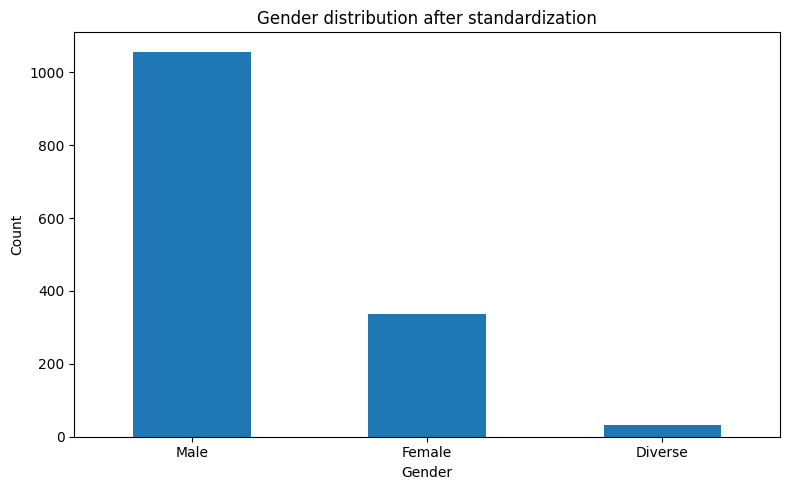

In [ ]:
# Visualization of the gender distribution after standardization

plt.figure(figsize=(8, 5))
df_clean['What is your gender?'].value_counts().plot(kind='bar')
plt.title('Gender distribution after standardization')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/gender_distribution.png', dpi=100)
plt.show()

The gender column was standardized from 70 unique spellings into the three main categories Male, Female and Diverse. Values that could not be meaningfully assigned were set to NaN. The visualization confirms that Male is the dominant group with 1057 participants, followed by Female with 337 and Diverse with 31.

#### 5.4 Work position standardization

In [ ]:
# Work position standardization into 7 categories where the primary role is determined by the first position listed

def standardize_position(val):
    if pd.isna(val):
        return np.nan
    
    primary = val.split('|')[0].strip()
    
    if primary in ['Back-end Developer', 'Front-end Developer', 'Designer']:
        return 'Developer'
    elif primary in ['DevOps/SysAdmin']:
        return 'DevOps'
    elif primary in ['Supervisor/Team Lead', 'Executive Leadership']:
        return 'Leadership'
    elif primary in ['Support', 'Sales', 'HR']:
        return 'Support'
    elif primary in ['Dev Evangelist/Advocate']:
        return 'Advocate'
    elif primary in ['One-person shop']:
        return 'One-person shop'
    else:
        return 'Other'

df_clean['Which of the following best describes your work position?'] = \
    df_clean['Which of the following best describes your work position?'].apply(standardize_position)

print(df_clean['Which of the following best describes your work position?'].value_counts(dropna=False))

Which of the following best describes your work position?
Developer          651
Leadership         250
Other              166
DevOps             137
One-person shop    104
Support             75
Advocate            50
Name: count, dtype: int64


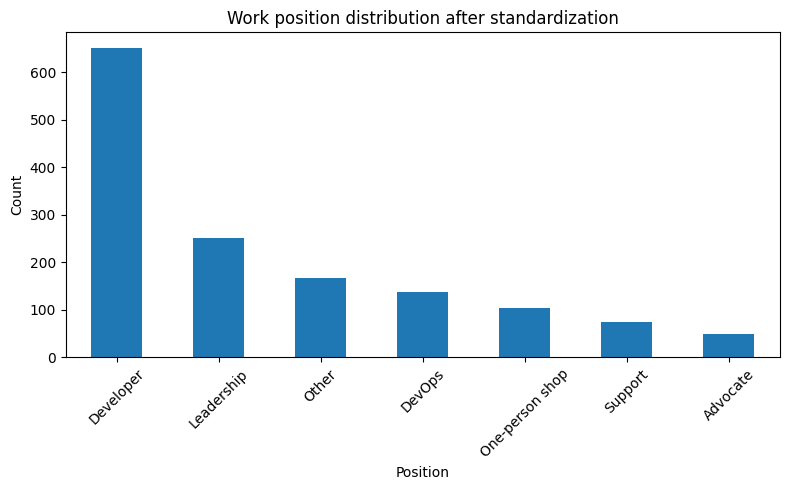

In [ ]:
# Visualization of the work position distribution after standardization

plt.figure(figsize=(8, 5))
df_clean['Which of the following best describes your work position?'].value_counts().plot(kind='bar')
plt.title('Work position distribution after standardization')
plt.xlabel('Position')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/work_position_distribution.png', dpi=100)
plt.show()

The work position column was standardized from 264 unique combinations into 7 categories, using the first value before the pipe separator as the primary role. As expected for a technology-focused survey, Developer is by far the largest group 
with 651 participants, followed by Leadership with 250 and Other with 166.

#### 5.5 Encoding

##### 5.5.1 Encoding strategy

Based on the column inspection in the EDA phase, each column will be assigned an encoding type depending on its answer structure. Columns with only two meaningful answers will be encoded as **binary** (0 = No, 1 = Yes). Columns with a standard No/Maybe/Yes structure will be encoded as **ordinal** (0/1/2). And columns with more specific answer scales recieve a **custom ordinal** mapping. *Gender* and *work position* will be encoded using One-hot encoding, and *age* can be used directly after outlier treatment.

In [ ]:
# Overview of all column values after preprocessing in order to determine if further cleaning steps are necessary

for i, col in enumerate(df_clean.columns):
    print(f"\n{i}: {col}")
    print(df_clean[col].value_counts(dropna=False))


0: Are you self-employed?
Are you self-employed?
0    1146
1     287
Name: count, dtype: int64

1: How many employees does your company or organization have?
How many employees does your company or organization have?
26-100            292
NaN               287
More than 1000    256
100-500           248
6-25              210
500-1000           80
1-5                60
Name: count, dtype: int64

2: Is your employer primarily a tech company/organization?
Is your employer primarily a tech company/organization?
1.0    883
NaN    287
0.0    263
Name: count, dtype: int64

3: Does your employer provide mental health benefits as part of healthcare coverage?
Does your employer provide mental health benefits as part of healthcare coverage?
NaN    689
Yes    531
No     213
Name: count, dtype: int64

4: Do you know the options for mental health care available under your employer-provided coverage?
Do you know the options for mental health care available under your employer-provided coverage?
NaN 

##### 5.5.2 Column encoding assignments

Based on the overview above, each column is assigned the following encoding type:

**Binary (10 Columns):**
*0 = No, 1 = Yes*
0, 2, 3, 5, 6, 12, 13, 31, 34, 35

**Ordinal (11 Columns):**
*0 = No, 1 = Maybe, 2 = Yes*
4, 8, 9, 10, 11, 24, 25, 29, 30, 32, 33

**Ordinal Custom (18 Columns)**
*column specific mapping*
1, 7, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 36, 37, 41

**Nominal (2 Columns):**
*One Hot Encoding:*
39, 40

**Numerical (1 Column):**
*direct use*
38

##### 5.5.3 Binary encoding

In [ ]:
# Binary encoding of 10 columns
# Column 'Are you self-employed?', 'Do you have previous employers?' and 'Have you ever sought treatment for a mental health issue from a mental health professional?' are already encoded

binary_columns = {
    'Is your employer primarily a tech company/organization?' : {1.0: 1, 0.0: 0},
    'Does your employer provide mental health benefits as part of healthcare coverage?' : {'Yes': 1, 'No': 0},
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?': {'Yes': 1, 'No': 0},
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?': {'Yes': 1, 'No': 0},
    'Do you feel that your employer takes mental health as seriously as physical health?': {'Yes': 1, 'No': 0},
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?': {'Yes': 1, 'No': 0},
    'Do you have a family history of mental illness?': {'Yes': 1, 'No': 0},
    'Have you been diagnosed with a mental health condition by a medical professional?': {'Yes': 1, 'No': 0}
}

for col, mapping in binary_columns.items():
    df_clean[col] = df_clean[col].map(mapping)
    
# Converting to nullable integer to keep 0 and 1 format

for col in binary_columns.keys():
    df_clean[col] = df_clean[col].astype('Int64')

# Verifying

for col in binary_columns.keys():
    print(df_clean[col].value_counts(dropna=False))
    print(f"\n")

Is your employer primarily a tech company/organization?
1       883
<NA>    287
0       263
Name: count, dtype: Int64


Does your employer provide mental health benefits as part of healthcare coverage?
<NA>    689
1       531
0       213
Name: count, dtype: Int64


Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
0       813
<NA>    390
1       230
Name: count, dtype: Int64


Does your employer offer resources to learn more about mental health concerns and options for seeking help?
<NA>    607
0       531
1       295
Name: count, dtype: Int64


Do you feel that your employer takes mental health as seriously as physical health?
<NA>    780
1       350
0       303
Name: count, dtype: Int64


Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?
0       1048
<NA>     287
1         98
Name: count, dtype: Int64


Do you have a fa

##### 5.5.4 Ordinal encoding

Before applying ordinal encoding, two columns require additional cleaning.

In [ ]:
# Replacing 'I am not sure' with 'Maybe' in column 'Do you know the options for mental health care available under your employer-provided coverage?' before ordinal encoding

df_clean['Do you know the options for mental health care available under your employer-provided coverage?'] = \
    df_clean['Do you know the options for mental health care available under your employer-provided coverage?'].replace('I am not sure', 'Maybe')

# Standardizing column 'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?' before ordinal encoding

df_clean['Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'] = \
    df_clean['Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'].replace({
        'Yes, I observed': 'Yes',
        'Yes, I experienced': 'Yes',
        'Maybe/Not sure': 'Maybe'
    })

# Verifying both columns

print(df_clean['Do you know the options for mental health care available under your employer-provided coverage?'].value_counts(dropna=False))
print()
print(df_clean['Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'].value_counts(dropna=False))

Do you know the options for mental health care available under your employer-provided coverage?
NaN      420
No       354
Maybe    352
Yes      307
Name: count, dtype: int64

Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?
No       567
Yes      431
Maybe    346
NaN       89
Name: count, dtype: int64


In [ ]:
# Ordinal encoding of 11 columns

ordinal_mapping = {'No': 0, 'Maybe': 1, 'Yes': 2}

ordinal_columns = [
    'Do you know the options for mental health care available under your employer-provided coverage?',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?',
    'Would you bring up a mental health issue with a potential employer in an interview?',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?',
    'Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?',
    'Have you had a mental health disorder in the past?',
    'Do you currently have a mental health disorder?'
]

for col in ordinal_columns:
    df_clean[col] = df_clean[col].map(ordinal_mapping)

# Converting to nullable integer

for col in ordinal_columns:
    df_clean[col] = df_clean[col].astype('Int64')

# Verifying

for col in ordinal_columns:
    print(df_clean[col].value_counts(dropna=False))
    print(f"\n")

Do you know the options for mental health care available under your employer-provided coverage?
<NA>    420
0       354
1       352
2       307
Name: count, dtype: Int64


Do you think that discussing a mental health disorder with your employer would have negative consequences?
1       487
0       438
<NA>    287
2       221
Name: count, dtype: Int64


Do you think that discussing a physical health issue with your employer would have negative consequences?
0       837
<NA>    287
1       268
2        41
Name: count, dtype: Int64


Would you feel comfortable discussing a mental health disorder with your coworkers?
1       479
0       392
<NA>    287
2       275
Name: count, dtype: Int64


Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?
2       428
1       382
0       336
<NA>    287
Name: count, dtype: Int64


Would you be willing to bring up a physical health issue with a potential employer in an interview?
1    633
0    441
2    359
Name:

##### 5.5.5 Ordinal custom encoding

In [ ]:
# Ordinal custom ecnoding of 18 columns
# Encoding the following columns with custom mappings based on their unique values

custom_ordinal_columns = {
    
    'How many employees does your company or organization have?': {
        '1-5': 1, '6-25': 2, '26-100': 3, '100-500': 4, '500-1000': 5, 'More than 1000': 6
    },
    
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': {
        'Very difficult': -2, 'Somewhat difficult': -1, 'Neither easy nor difficult': 0, 'Somewhat easy': 1, 'Very easy': 2
    },
    
    'Have your previous employers provided mental health benefits?': {
        'No, none did': 0, 'Some did': 1, 'Yes, they all did': 2
    },
    
    'Were you aware of the options for mental health care provided by your previous employers?': {
        'No, I only became aware later': 0, 'I was aware of some': 1, 'Yes, I was aware of all of them': 2
    },
    
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?': {
        'None did': 0, 'Some did': 1, 'Yes, they all did': 2
    },
    
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?': {
        'None did': 0, 'Some did': 1, 'Yes, they all did': 2
    },
    
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?': {
        'Yes, all of them': 0, 'Some of them': 1, 'None of them': 2
    },
    
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?': {
        'Yes, all of them': 0, 'Some of them': 1, 'None of them': 2
    },
    
    'Would you have been willing to discuss a mental health issue with your previous co-workers?': {
        'No, at none of my previous employers': 0, 'Some of my previous employers': 1, 'Yes, at all of my previous employers': 2
    },
    
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?': {
        'No, at none of my previous employers': 0, 'Some of my previous employers': 1, 'Yes, at all of my previous employers': 2
    },
    
    'Did you feel that your previous employers took mental health as seriously as physical health?': {
        'None did': 0, 'Some did': 1, 'Yes, they all did': 2
    },
    
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?': {
        'Yes, all of them': 0, 'Some of them': 1, 'None of them': 2
    },
    
    'Do you feel that being identified as a person with a mental health issue would hurt your career?': {
        'Yes, it has': -2, 'Yes, I think it would': -1, 'Maybe': 0, "No, I don't think it would": 1, 'No, it has not': 2
    },
    
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?': {
        'Yes, they do': -2, 'Yes, I think they would': -1, 'Maybe': 0, "No, I don't think they would": 1, 'No, they do not': 2
    },
    
    'How willing would you be to share with friends and family that you have a mental illness?': {
        'Not open at all': -2, 'Somewhat not open': -1, 'Neutral': 0, 'Somewhat open': 1, 'Very open': 2
    },
    
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': {
        'Often': 0, 'Sometimes': 1, 'Rarely': 2, 'Never': 3
    },
    
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': {
        'Often': 0, 'Sometimes': 1, 'Rarely': 2, 'Never': 3
    },
    
    'Do you work remotely?': {
        'Never': 0, 'Sometimes': 1, 'Always': 2
    }
}

for col, mapping in custom_ordinal_columns.items():
    df_clean[col] = df_clean[col].map(mapping)

# Converting to nullable integer

for col in custom_ordinal_columns.keys():
    df_clean[col] = df_clean[col].astype('Int64')

# Verifying

for col in custom_ordinal_columns.keys():
    print(df_clean[col].value_counts(dropna=False))
    print(f"\n")

How many employees does your company or organization have?
3       292
<NA>    287
6       256
4       248
2       210
5        80
1        60
Name: count, dtype: Int64


If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
<NA>    437
1       281
2       220
-1      199
0       178
-2      118
Name: count, dtype: Int64


Have your previous employers provided mental health benefits?
<NA>    482
1       391
0       372
2       188
Name: count, dtype: Int64


Were you aware of the options for mental health care provided by your previous employers?
<NA>    751
1       384
2       181
0       117
Name: count, dtype: Int64


Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?
0       890
1       255
<NA>    255
2        33
Name: count, dtype: Int64


Did your previous employers provide resources to learn more about mental health issues and how to seek help?
0 

##### 5.5.6 Nominal encoding

In [ ]:
# One-hot encoding of the 2 columns 'What is your gender?' and 'Which of the following best describes your work position?'
# One-hot encoding for gender column

df_clean = pd.get_dummies(df_clean,
                          columns=['What is your gender?'],
                          prefix='gender',
                          dtype=int)

# One-hot encoding for work position column

df_clean = pd.get_dummies(df_clean,
                          columns=['Which of the following best describes your work position?'],
                          prefix='position',
                          dtype=int)

# Verifying

print(f"Columns after One-Hot encoding: {df_clean.shape[1]}")
print(f"\nGender columns:")
print([col for col in df_clean.columns if col.startswith('gender')])

print(f"\nPosition columns:")
print([col for col in df_clean.columns if col.startswith('position')])

Columns after One-Hot encoding: 51

Gender columns:
['gender_Diverse', 'gender_Female', 'gender_Male']

Position columns:
['position_Advocate', 'position_DevOps', 'position_Developer', 'position_Leadership', 'position_One-person shop', 'position_Other', 'position_Support']


In [ ]:
# Final overview of all columns after encoding to verify correct encoding before imputation

for i, col in enumerate(df_clean.columns):
    print(f"\n{i}: {col}")
    print(df_clean[col].value_counts(dropna=False))


0: Are you self-employed?
Are you self-employed?
0    1146
1     287
Name: count, dtype: int64

1: How many employees does your company or organization have?
How many employees does your company or organization have?
3       292
<NA>    287
6       256
4       248
2       210
5        80
1        60
Name: count, dtype: Int64

2: Is your employer primarily a tech company/organization?
Is your employer primarily a tech company/organization?
1       883
<NA>    287
0       263
Name: count, dtype: Int64

3: Does your employer provide mental health benefits as part of healthcare coverage?
Does your employer provide mental health benefits as part of healthcare coverage?
<NA>    689
1       531
0       213
Name: count, dtype: Int64

4: Do you know the options for mental health care available under your employer-provided coverage?
Do you know the options for mental health care available under your employer-provided coverage?
<NA>    420
0       354
1       352
2       307
Name: count, dtype: 

#### 5.6 Missing value imputation

In [ ]:
# Checking missing values after encoding

missing_final = df_clean.isnull().sum()
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)

print(f"Columns with missing values: {len(missing_final)}")
print(f"Total missing values: {missing_final.sum()}")
print(f"\n{missing_final}")

# Storing for visualization

missing_before = missing_final.sum()

Columns with missing values: 30
Total missing values: 11029

Do you feel that your employer takes mental health as seriously as physical health?                                                                                                 780
Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?    776
Were you aware of the options for mental health care provided by your previous employers?                                                                                           751
Does your employer provide mental health benefits as part of healthcare coverage?                                                                                                   689
Does your employer offer resources to learn more about mental health concerns and options for seeking help?                                                                         607
If you have a menta

##### 5.6.1 Imputation strategy

After encoding, 30 columns still contain missing values with a total of 11029 missing entries. Based on the structural patterns identified during the EDA phase, three different imputation strategies are applied:

- **Structural missing values** from self-employed participants (287) and participants without previous employers (169) are replaced with -3, as these represent non-applicable questions rather than missing information.
- **Age** missing values will be replaced with the median age
- **Remaining missing values** will be replaced with the column mode

##### 5.6.2 Structural missing values

In [ ]:
# Identifying and replacing all structural missing values
# 287 corresponds to self-employed participants
# 169 corresponds to participants without previous employers

structural_cols = [col for col in df_clean.columns 
                   if df_clean[col].isnull().sum() in [287, 169]]

print(f"Columns with structural missing values: {len(structural_cols)}")
for col in structural_cols:
    print(f"- {col} ({df_clean[col].isnull().sum()} NaN)")

for col in structural_cols:
    df_clean[col] = df_clean[col].fillna(-3)

print("\nMissing values after structural imputation:")
print(df_clean[structural_cols].isnull().sum())

Columns with structural missing values: 11
- How many employees does your company or organization have? (287 NaN)
- Is your employer primarily a tech company/organization? (287 NaN)
- Do you think that discussing a mental health disorder with your employer would have negative consequences? (287 NaN)
- Do you think that discussing a physical health issue with your employer would have negative consequences? (287 NaN)
- Would you feel comfortable discussing a mental health disorder with your coworkers? (287 NaN)
- Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)? (287 NaN)
- Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace? (287 NaN)
- Did your previous employers provide resources to learn more about mental health issues and how to seek help? (169 NaN)
- Do you think that discussing a physical health issue with previous employers would have negative consequences? 

##### 5.6.3 Age imputation

In [ ]:
# Imputing missing age values with the median age of the dataset

age_median = int(df_clean['What is your age?'].median())
print(f"Age median: {age_median}")

df_clean['What is your age?'] = df_clean['What is your age?'].fillna(age_median)

# Converting to integer after imputation

df_clean['What is your age?'] = df_clean['What is your age?'].astype(int)

print(f"Missing values in age column after imputation: {df_clean['What is your age?'].isnull().sum()}")
print(f"Age range after imputation: {df_clean['What is your age?'].min()} - {df_clean['What is your age?'].max()}")

Age median: 33
Missing values in age column after imputation: 0
Age range after imputation: 19 - 66


##### 5.6.4 Checking remaining missing values

In [ ]:
#Checking remaining missing values after preprocessing

missing_remaining = df_clean.isnull().sum()
missing_remaining = missing_remaining[missing_remaining > 0].sort_values(ascending=False)

print(f"Columns with remaining missing values: {len(missing_remaining)}")
print(f"Total missing values: {missing_remaining.sum()}")
print()
print(missing_remaining)

Columns with remaining missing values: 18
Total missing values: 8337

Do you feel that your employer takes mental health as seriously as physical health?                                                                                                 780
Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?    776
Were you aware of the options for mental health care provided by your previous employers?                                                                                           751
Does your employer provide mental health benefits as part of healthcare coverage?                                                                                                   689
Does your employer offer resources to learn more about mental health concerns and options for seeking help?                                                                         607
If you hav

##### 5.6.5 Mode imputation for remaining missing values

In [ ]:
# Mode imputation for remaining columns with missing values
# As all remaining NaN or N/A values represent knowledge gaps, they are replaced with the most frequent value of each column

missing_columns = [col for col in df_clean.columns if df_clean[col].isnull().sum() > 0]

print(f"Columns with remaining missing values: {len(missing_columns)}")
print()

for col in missing_columns:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"- {col} — imputed with mode: {mode_val}")

print(f"\nTotal missing values after imputation: {df_clean.isnull().sum().sum()}")

Columns with remaining missing values: 18

- Does your employer provide mental health benefits as part of healthcare coverage? — imputed with mode: 1
- Do you know the options for mental health care available under your employer-provided coverage? — imputed with mode: 0
- Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)? — imputed with mode: 0
- Does your employer offer resources to learn more about mental health concerns and options for seeking help? — imputed with mode: 0
- If a mental health issue prompted you to request a medical leave from work, asking for that leave would be: — imputed with mode: 1
- Do you feel that your employer takes mental health as seriously as physical health? — imputed with mode: 1
- Have your previous employers provided mental health benefits? — imputed with mode: 1
- Were you aware of the options for mental health care provided by your previous employers? — imputed with 

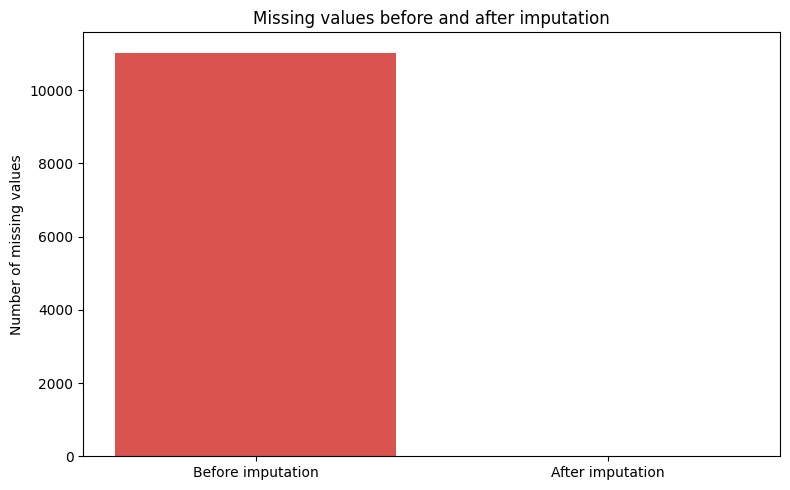

In [ ]:
# Missing value overview before and after imputation

missing_after = df_clean.isnull().sum().sum()

labels = ['Before imputation', 'After imputation']
values = [missing_before, missing_after]

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color=['#d9534f', '#5cb85c'])
plt.title('Missing values before and after imputation')
plt.ylabel('Number of missing values')
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/missing_values_imputation.png', dpi=100)
plt.show()

In [ ]:
# Final check after imputation

print(f"Shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Data types:\n{df_clean.dtypes.value_counts()}")

Shape: (1433, 51)
Missing values: 0
Data types:
Int64    37
int64    14
Name: count, dtype: int64


#### 5.7 Scaling

After encoding, the features have different value ranges. Binary columns range from 0 to 1, ordinal columns from 0 to 2, custom ordinal columns from -3 to 6 and age from 19 to 66. Without scaling, features with larger ranges would 
dominate the clustering. StandardScaler will therefore be applied to transform all features to a mean of 0 and a standard deviation of 1.

In [ ]:
# Standardizing dataset for clustering and PCA

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean),
    columns=df_clean.columns
)

print(f"Shape after scaling: {df_scaled.shape}")
print(f"\nMean values (should be ~0):")
print(df_scaled.mean().round(2).head())
print(f"\nStd values (should be ~1):")
print(df_scaled.std().round(2).head())

Shape after scaling: (1433, 51)

Mean values (should be ~0):
Are you self-employed?                                                                             0.0
How many employees does your company or organization have?                                         0.0
Is your employer primarily a tech company/organization?                                           -0.0
Does your employer provide mental health benefits as part of healthcare coverage?                  0.0
Do you know the options for mental health care available under your employer-provided coverage?    0.0
dtype: float64

Std values (should be ~1):
Are you self-employed?                                                                             1.0
How many employees does your company or organization have?                                         1.0
Is your employer primarily a tech company/organization?                                            1.0
Does your employer provide mental health benefits as part of healthcare 

#### 5.8 Preprocessing summary

The preprocessing phase transformed the raw dataset into a format suitable for clustering:

- Non-answers were converted to NaN before encoding to ensure they would not be treated as meaningful responses.

- Age outliers outside the range of 18 to 67 were replaced with NaN and later imputed with the median age of 33.

- Gender and work position were standardized from 70 and 264 unique values into 3 and 7 categories respectively.

All columns were encoded based on their answer structure. Therefore, binary, ordinal, custom ordinal and nominal encoding was applied. Two columns required additional cleaning during the encoding phase that had not been identified earlier. Structural missing values from self-employed participants and participants without previous employers were replaced with -3, while remaining missing values were imputed with the column mode. Finally, all features were scaled using StandardScaler to ensure equal weighting in the clustering algorithm.

The final dataset contains 1433 rows and 51 columns with no remaining missing values.

### 6. Dimensionality Reduction

With 51 features after preprocessing, the dimensionality of the dataset is too high for direct clustering. Therefore, PCA is applied to reduce the number of features while preserving the main characteristics of the data. It also helps to reduce noise and multicollinearity between features, and enables a 2D visualization of the clustering results.

#### 6.1 PCA variance analysis and application

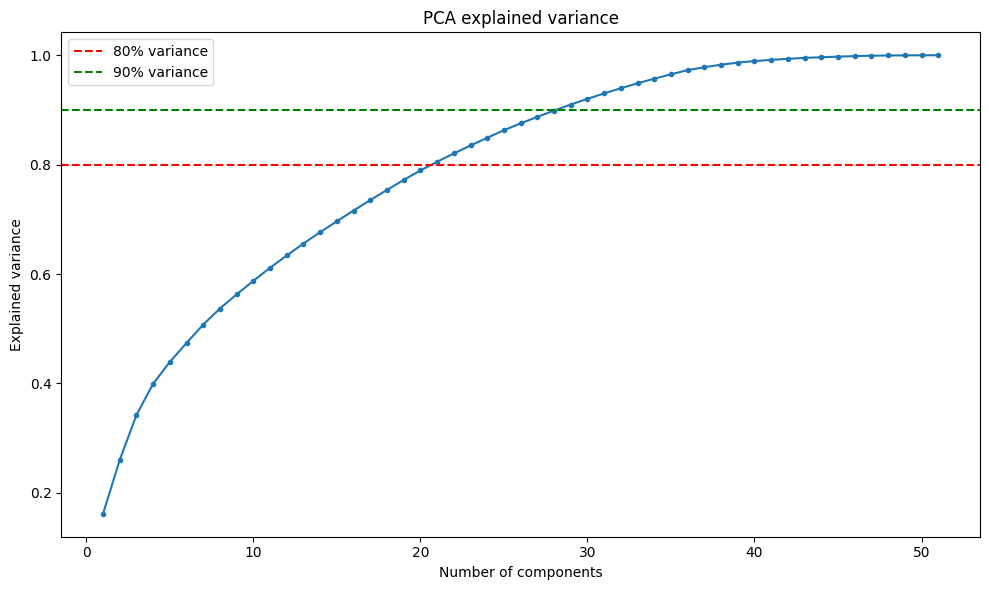

Components needed for 80% variance: 21
Components needed for 90% variance: 29


In [ ]:
# Applying PCA to evaluate dimensionality reduction potential

from sklearn.decomposition import PCA
import numpy as np

# Fit PCA using all components

pca_full = PCA()
pca_full.fit(df_scaled)

# Calculating cumulative explained variance

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plotting explained variance

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=3)
plt.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.title('PCA explained variance')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/pca_variance.png', dpi=100)
plt.show()

# Displaying how many components needed for 80% and 90% variance

for threshold in [0.80, 0.90]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Components needed for {int(threshold*100)}% variance: {n_components}")

The cumulative variance plot shows that 21 components are needed to explain 80% of the total variance and 29 components for 90%. A threshold of 80% will be chosen as a balance between dimensionality reduction and information preservation.

In [ ]:
# Applying PCA with 21 components retaining 80% of explained variance

pca = PCA(n_components=21)
df_pca = pca.fit_transform(df_scaled)

print(f"Shape before PCA: {df_scaled.shape}")
print(f"Shape after PCA: {df_pca.shape}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum().round(3)}")

Shape before PCA: (1433, 51)
Shape after PCA: (1433, 21)
Total explained variance: 0.805


### 6.2 Visualization

Shape for visualization: (1433, 2)
Explained variance (2 components): 0.26


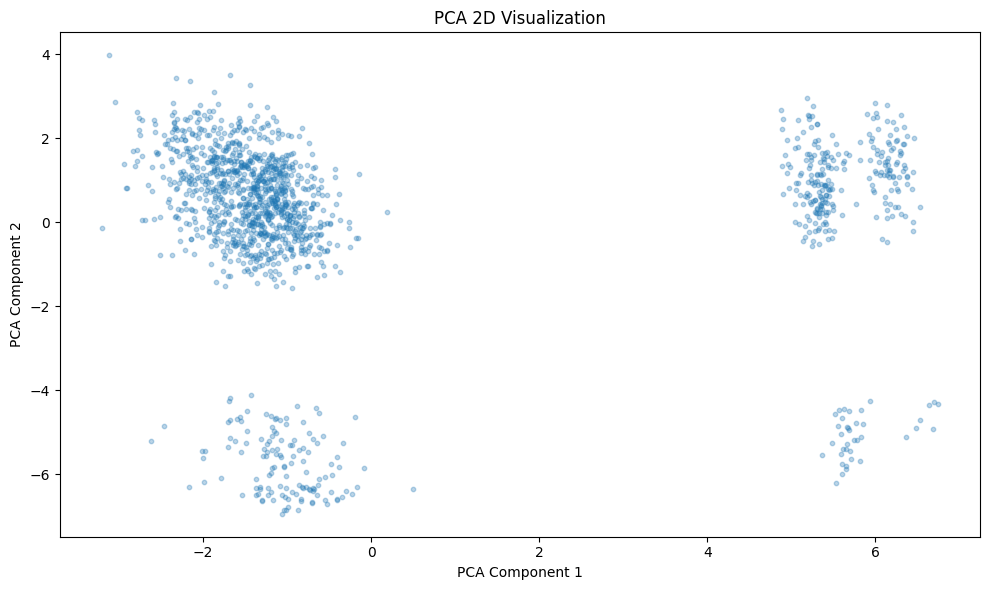

In [ ]:
# PCA with 2 components for visualization purposes only

pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

print(f"Shape for visualization: {df_pca_2d.shape}")
print(f"Explained variance (2 components): {pca_2d.explained_variance_ratio_.sum().round(3)}")

# Plot visualization of PCA with 2 components

plt.figure(figsize=(10, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], alpha=0.3, s=10)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA 2D Visualization')
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/pca_2d.png', dpi=100)
plt.show()

The 2D visualization shows that the data points are not evenly distributed. There appears to be a clear separation along the first principal component — a large group of data points on the left side and a smaller but distinct group on the right side. Additionally, within both sides there seems to be some vertical separation along the second principal component.

This unexpected pattern suggests that one or more variables are strongly dominating the principal components and creating artificial groupings. Further investigation is needed to identify which features are driving this separation before proceeding with clustering.

In [ ]:
# Investigating which features drive the separation in the 2D visualization

pc1_loadings = pd.Series(pca_2d.components_[0], index=df_scaled.columns)
pc2_loadings = pd.Series(pca_2d.components_[1], index=df_scaled.columns)

print("Features driving PC1:")
print(pc1_loadings.abs().sort_values(ascending=False).head(10))
print("\nFeatures driving PC2:")
print(pc2_loadings.abs().sort_values(ascending=False).head(10))

Features driving PC1:
Are you self-employed?                                                                                                                 0.342701
Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?    0.339039
Is your employer primarily a tech company/organization?                                                                                0.332442
Do you think that discussing a physical health issue with your employer would have negative consequences?                              0.327608
Would you feel comfortable discussing a mental health disorder with your coworkers?                                                    0.321086
Do you think that discussing a mental health disorder with your employer would have negative consequences?                             0.319432
Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?                    

The loading analysis shows that PC1 is mainly driven by self-employment status and employer-related features, while PC2 is dominated by previous employer questions. Both groups of features were encoded with -3, which is giving the idea, that the separation seen in the plot is probably due to these features. Since the HR program targets company employees, self-employed participants will be removed and the PCA will be applied again on the filtered dataset.

### 6.3 Filtering self-employed individuals

In [ ]:
# Removing self-employed individuals from clustering analysis

df_employees = df_clean[df_clean['Are you self-employed?'] == 0].copy()
df_scaled_employees = df_scaled[df_clean['Are you self-employed?'] == 0].copy()

print(f"Shape before filtering: {df_clean.shape}")
print(f"Shape after filtering: {df_employees.shape}")
print(f"Removed: {df_clean.shape[0] - df_employees.shape[0]} self-employed individuals")

Shape before filtering: (1433, 51)
Shape after filtering: (1146, 51)
Removed: 287 self-employed individuals


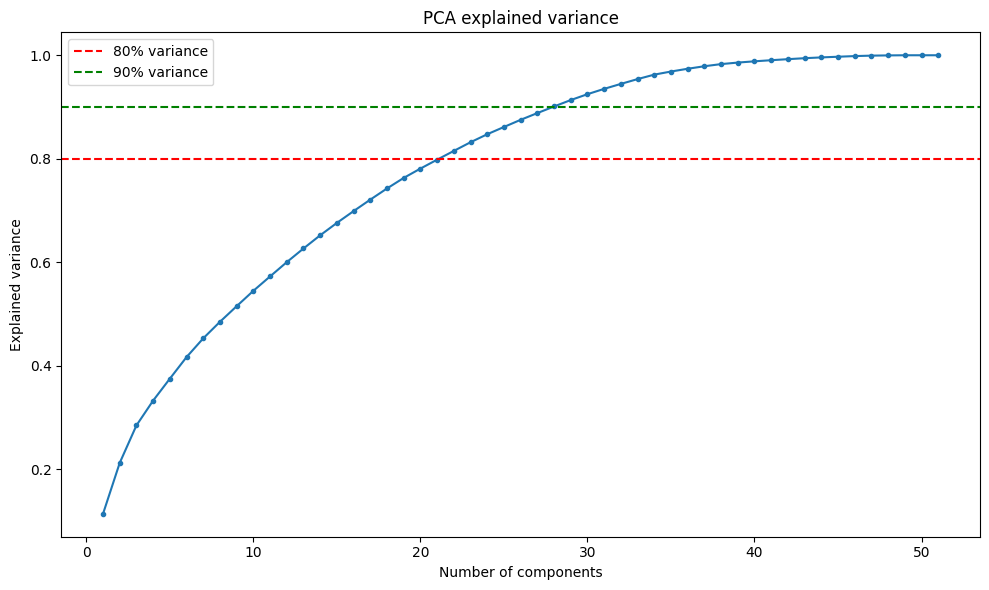

Components needed for 80% variance: 22
Components needed for 90% variance: 28


In [ ]:
# Reanalyzing cumulative explained variance after filtering self-employed

pca_full = PCA()
pca_full.fit(df_scaled_employees)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=3)
plt.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.title('PCA explained variance')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/pca_variance_employees.png', dpi=100)
plt.show()

for threshold in [0.80, 0.90]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Components needed for {int(threshold*100)}% variance: {n_components}")

In [ ]:
# PCA with 22 components on filtered dataset containing employees only

pca = PCA(n_components=22)
df_pca = pca.fit_transform(df_scaled_employees)

print(f"Shape after PCA: {df_pca.shape}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum().round(3)}")

Shape after PCA: (1146, 22)
Total explained variance: 0.815


Explained variance (2 components): 0.213


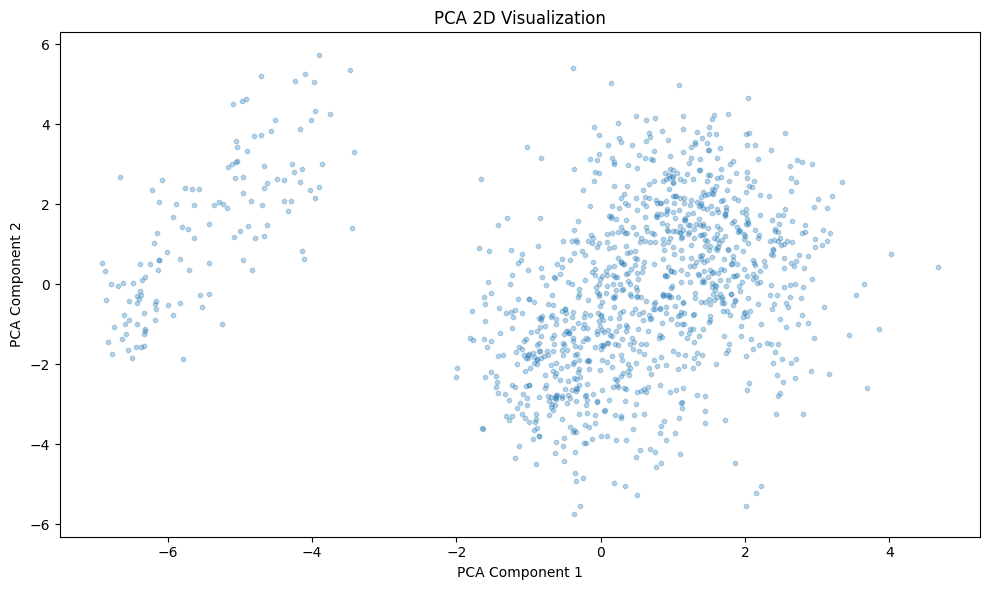

In [ ]:
# 2D PCA on filtered dataset for visualization

pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled_employees)

print(f"Explained variance (2 components): {pca_2d.explained_variance_ratio_.sum().round(3)}")

plt.figure(figsize=(10, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], alpha=0.3, s=10)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA 2D Visualization')
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/pca_2d_employees.png', dpi=100)
plt.show()

After removing self-employed participants, the 2D visualization shows a much more natural distribution. The extreme separation seen in the previous plot has disappeared, confirming that it was caused by the self-employed participants. However, a small group of data points remains visibly separated in the upper left area, suggesting that another structural pattern may still be present in the data. Likely it is related to participants without previous employer experience.

In [ ]:
# Investigating which features drive the remaining separation

pca_2d_employees = PCA(n_components=2)
pca_2d_employees.fit(df_scaled_employees)

pc1_loadings = pd.Series(pca_2d_employees.components_[0], index=df_scaled_employees.columns)
pc2_loadings = pd.Series(pca_2d_employees.components_[1], index=df_scaled_employees.columns)

print("Features driving PC1:")
print(pc1_loadings.abs().sort_values(ascending=False).head(10))
print("\nFeatures driving PC2:")
print(pc2_loadings.abs().sort_values(ascending=False).head(10))

Features driving PC1:
Did your previous employers provide resources to learn more about mental health issues and how to seek help?                         0.393957
Do you have previous employers?                                                                                                      0.376931
Do you think that discussing a physical health issue with previous employers would have negative consequences?                       0.365774
Would you have been willing to discuss a mental health issue with your previous co-workers?                                          0.364838
Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?               0.351012
Have you had a mental health disorder in the past?                                                                                   0.181974
Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communicatio

To check whether removing the column 'Do you have previous employers?' eliminates the separation, the column will be temporarily dropped and the 2D visualization will be repeated.

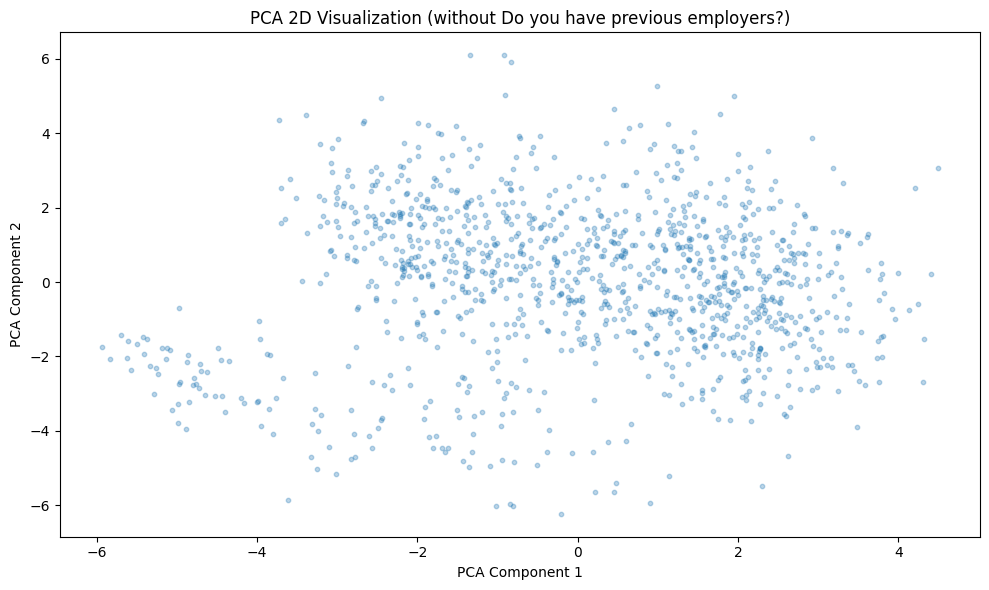

In [ ]:
# Testing impact of removing 'Do you have previous employers?' column

df_scaled_test = df_scaled_employees.drop(columns=['Do you have previous employers?'])

pca_test = PCA(n_components=2)
df_pca_test = pca_test.fit_transform(df_scaled_test)

plt.figure(figsize=(10, 6))
plt.scatter(df_pca_test[:, 0], df_pca_test[:, 1], alpha=0.3, s=10)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA 2D Visualization (without Do you have previous employers?)')
plt.tight_layout()
plt.show()

In [ ]:
# Investigating which features drive the separation after removing 'Do you have previous employers?'

pc1_loadings_test = pd.Series(pca_test.components_[0], index=df_scaled_test.columns)
pc2_loadings_test = pd.Series(pca_test.components_[1], index=df_scaled_test.columns)

print("Top features driving PC1:")
print(pc1_loadings_test.abs().sort_values(ascending=False).head(10))
print("\nTop features driving PC2:")
print(pc2_loadings_test.abs().sort_values(ascending=False).head(10))

Top features driving PC1:
Have you had a mental health disorder in the past?                                                                                            0.345701
Have you been diagnosed with a mental health condition by a medical professional?                                                             0.333574
Have you ever sought treatment for a mental health issue from a mental health professional?                                                   0.332451
Do you currently have a mental health disorder?                                                                                               0.302418
Did your previous employers provide resources to learn more about mental health issues and how to seek help?                                  0.259230
Do you have a family history of mental illness?                                                                                               0.231852
Do you think that discussing a physical health issue with previous e

Removing 'Do you have previous employers?' did not eliminate the separation. Instead, the group simply shifted in the plot and PC2 is still dominated by previous employer columns. This confirms that the cause are the -3 values across all previous employer columns rather than this single indicator. Therefore, no further filtering will be applied. The PCA with 22 components on the employee 
dataset is therefore used as the basis for clustering.

### 6.4 Dimensionality Reduction Summary

The dimensionality reduction phase started with a PCA on the full dataset, revealing that 21 components are needed to explain 80% of the variance. The 2D visualization showed an unexpected separation in the data, which was investigated through a loading analysis. This revealed that the separation was caused by the -3 encoded structural missing values of self-employed participants and participants without previous employer experience.

Since the HR program targets company employees, self-employed participants were removed. After filtering, the PCA was repeated on the employee dataset, requiring 22 components to explain 81.2% of the variance. The 2D visualization still showed a small separated group, which was investigated further.

Hence, a hypothesis was tested. Removing 'Do you have previous employers?' did not eliminate the separation, confirming that it is caused by the -3 values across all previous employer columns. Since these participants are part of the target population, no further 
filtering was applied.

Therefore, the final dataset that will be used for clustering contains 1146 employees and 22 principal components.

### 7. Clustering

With the dimensionality-reduced dataset of 1146 employees and 22 principal components, the next step is to identify natural groups within the data. Therefore, K-Means clustering will be applied as it is a well-established and computationally efficient method for unsupervised grouping.
But before applying K-Means, the optimal number of clusters needs to be determined using the Elbow method and Silhouette Score.

#### 7.1 Determining the optimal number of clusters
##### 7.1.1 Elbow method

Dataset used for clustering: (1146, 22)


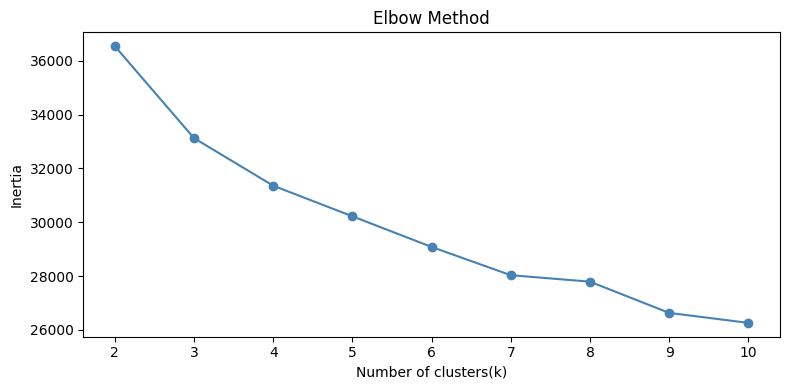

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Verifying correct dataset

print(f"Dataset used for clustering: {df_pca.shape}")

# Using the elbow method to estimate the optimal number of clusters

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_pca)
    inertias.append(km.inertia_)
    
# Plotting the results

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method')
plt.xlabel('Number of clusters(k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [ ]:
# Calculating the drop between each k

drops = []
for i in range(1, len(inertias)):
    drop = inertias[i-1] - inertias[i]
    drops.append(drop)
    print(f"k={i+2}: drop from k={i+1} = {drop:.0f}")

k=3: drop from k=2 = 3416
k=4: drop from k=3 = 1766
k=5: drop from k=4 = 1137
k=6: drop from k=5 = 1138
k=7: drop from k=6 = 1050
k=8: drop from k=7 = 240
k=9: drop from k=8 = 1160
k=10: drop from k=9 = 371


The elbow method shows no distinct kink in the curve. But calculated is the strongest drop  between k=2 and k=3 (3416), after which the drops decrease notably from 1766 between k=3 and k=4 to only 1137 between k=4 and k=5. The Silhouette Score will therefore be used as a second method to make a more informed decision.

##### 7.1.2 Silhouette score

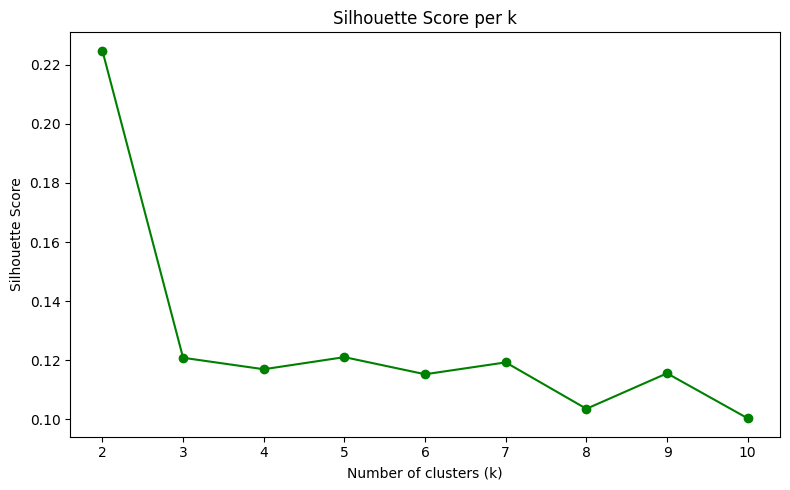

k=2: Silhouette Score = 0.225
k=3: Silhouette Score = 0.121
k=4: Silhouette Score = 0.117
k=5: Silhouette Score = 0.121
k=6: Silhouette Score = 0.115
k=7: Silhouette Score = 0.119
k=8: Silhouette Score = 0.104
k=9: Silhouette Score = 0.116
k=10: Silhouette Score = 0.100


In [ ]:
# Using the silhouette score to confirm optimal k

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    silhouette_scores.append(silhouette_score(df_pca, kmeans.labels_))

# Plotting the silhouette score

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per k')
plt.tight_layout()
plt.savefig('/Users/fessnaldo/Desktop/Case_Study_ML/outputs/silhouette.png', dpi=100)
plt.show()

# Displaying scores

for k, score in zip(k_range, silhouette_scores):
    print(f"k={k}: Silhouette Score = {score:.3f}")

As the Silhouette Score peaks at k=2 (0.225), which is surprisingly high, further investigations will be made, before drawing conclusions.

In [ ]:
# Checking cluster distribution for k=2

km_test = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_test = km_test.fit_predict(df_pca)
print(pd.Series(labels_test).value_counts())

1    1015
0     131
Name: count, dtype: int64


The k=2 clustering simply separates the 131 participants without previous employer experience from the remaining 1015 participants. This confirms that the high score at k=2 is not a meaningful clustering result but rather a consequence of the -3 encoded values. Therefore, k=2 will be excluded from the analysis.

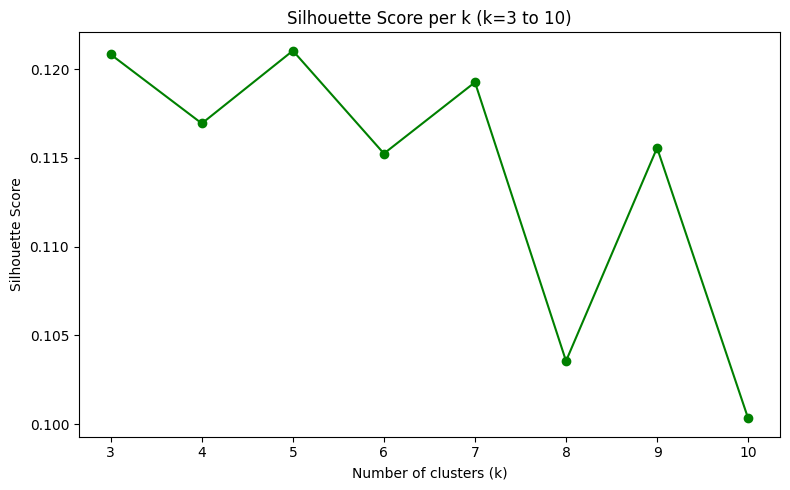

k=3: Silhouette Score = 0.121
k=4: Silhouette Score = 0.117
k=5: Silhouette Score = 0.121
k=6: Silhouette Score = 0.115
k=7: Silhouette Score = 0.119
k=8: Silhouette Score = 0.104
k=9: Silhouette Score = 0.116
k=10: Silhouette Score = 0.100


In [ ]:
# Silhouette Score excluding k=2 due to non-meaningful clustering result

silhouette_scores = []
k_range_adjusted = range(3, 11)

for k in k_range_adjusted:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    silhouette_scores.append(silhouette_score(df_pca, kmeans.labels_))

plt.figure(figsize=(8, 5))
plt.plot(k_range_adjusted, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per k (k=3 to 10)')
plt.tight_layout()
plt.show()

for k, score in zip(k_range_adjusted, silhouette_scores):
    print(f"k={k}: Silhouette Score = {score:.3f}")

Excluding k=2, the Silhouette Score peaks at k=3 and k=5, both with 0.121. Combined with the Elbow Method, where the drop from k=3 to k=4 (1766) is notably larger than the drop from k=4 to k=5 (1137) and knowing that one cluster will likely capture the participants without previous employer experience, k=4 is selected as the optimal number of clusters.

##### 7.1.3 K-Means with k=4

In [ ]:
from sklearn.cluster import KMeans

# Defining k based on the elbow method and silhouette score

best_k = 4

# Fitting the final KMeans model with the optimal number of clusters

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_pca)

# Adding cluster labels for further analysis

df_employees['cluster'] = cluster_labels

print(f"Cluster distribution (k={best_k}):")
print(df_employees['cluster'].value_counts().sort_index())

Cluster distribution (k=4):
cluster
0    399
1    268
2    348
3    131
Name: count, dtype: int64


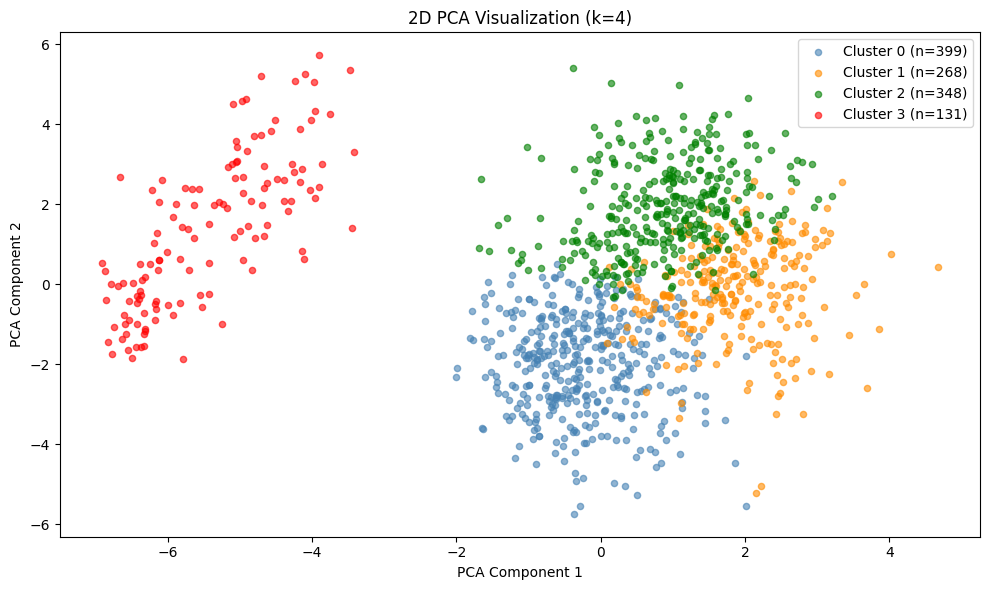

In [ ]:
# Visualizing clusters using the already computed 2D PCA coordinates

colors = ['steelblue', 'darkorange', 'green', 'red']

plt.figure(figsize=(10, 6))
for i in range(best_k):
    mask = cluster_labels == i
    plt.scatter(
        df_pca_2d[mask, 0],
        df_pca_2d[mask, 1],
        c=colors[i],
        label=f'Cluster {i} (n={mask.sum()})',
        alpha=0.6,
        s=20
    )

plt.title(f'2D PCA Visualization (k={best_k})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

The 2D visualization shows that Cluster 3 (red) is clearly separated on the left, which is consistent with the participants without previous employer experience. The other three clusters overlap in the right area, which is expected since the 2D plot only shows a small part of the total variance. The next step is to analyze the cluster profiles to understand what characterizes each group.

#### 7.2 Cluster Profile Analysis
##### 7.2.1 Mean feature values per cluster

In [ ]:
# Mean values of the original features per cluster to understand the characteristics of each cluster

cluster_profiles = df_employees.groupby('cluster').mean(numeric_only=True)

cluster_profiles

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,...,gender_Diverse,gender_Female,gender_Male,position_Advocate,position_DevOps,position_Developer,position_Leadership,position_One-person shop,position_Other,position_Support
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.0,3.568922,0.781955,0.786967,0.591479,0.165414,0.18797,0.716792,0.609023,0.220551,...,0.000000,0.132832,0.867168,0.022556,0.077694,0.561404,0.182957,0.005013,0.105263,0.045113
1,0.0,4.037313,0.791045,0.936567,1.309701,0.36194,0.488806,0.940299,0.44403,0.152985,...,0.026119,0.182836,0.787313,0.104478,0.138060,0.350746,0.257463,0.000000,0.111940,0.037313
2,0.0,3.681034,0.758621,0.761494,0.801724,0.12069,0.172414,-0.436782,1.275862,0.502874,...,0.045977,0.396552,0.543103,0.022989,0.112069,0.454023,0.163793,0.008621,0.152299,0.086207
3,0.0,3.793893,0.725191,0.78626,0.763359,0.19084,0.221374,0.381679,0.938931,0.351145,...,0.030534,0.206107,0.763359,0.015267,0.053435,0.641221,0.106870,0.015267,0.106870,0.061069


In [75]:
# Identifying the most differentiating features between clusters

feature_variance = cluster_profiles.var(axis=0)
top_features = feature_variance.nlargest(15).index

cluster_profiles[top_features]

,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,What is your age?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Have you had a mental health disorder in the past?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you currently have a mental health disorder?,Do you have previous employers?,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?,Have you been diagnosed with a mental health condition by a medical professional?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Have you ever sought treatment for a mental health issue from a mental health professional?,Do you think that discussing a mental health disorder with your employer would have negative consequences?
cluster,,,,,,,,,,,,,,,
0,1.724311,1.453634,33.170426,0.776942,0.300752,0.350877,0.716792,0.293233,1.0,-0.253133,0.125313,0.027569,1.197995,0.125313,0.609023
1,1.600746,1.488806,33.850746,0.876866,0.66791,1.776119,0.940299,1.529851,1.0,0.13806,0.492537,0.847015,1.526119,0.925373,0.44403
2,1.390805,1.224138,34.353448,0.528736,0.341954,1.761494,-0.436782,1.468391,1.0,-0.91954,-0.477011,0.795977,0.704023,0.862069,1.275862
3,-3.0,-3.0,29.916031,-3.0,-3.0,0.923664,0.381679,0.900763,0.0,-0.412214,0.053435,0.396947,0.80916,0.450382,0.938931


##### 7.2.2 Heatmap of the cluster profiles

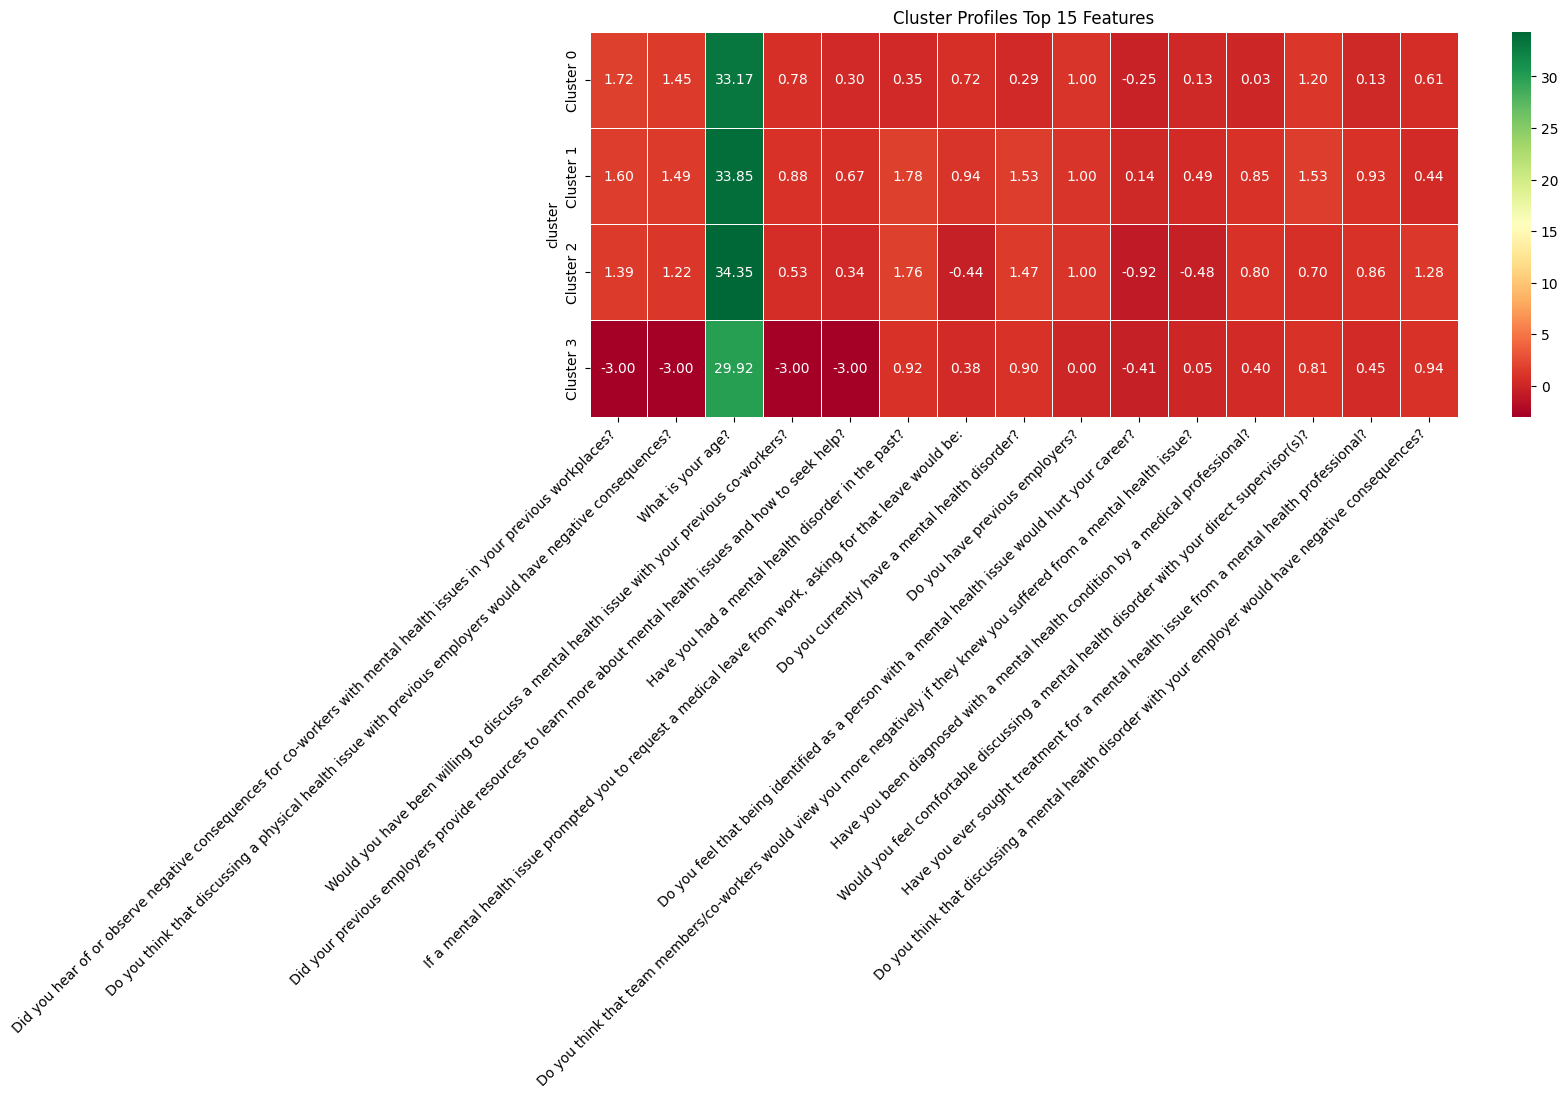

In [ ]:
# Visualization after adding .astype(float) to resolve dtype issue

import seaborn as sns

plt.figure(figsize=(14, 5))
sns.heatmap(
    cluster_profiles[top_features].astype(float),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    yticklabels=[f'Cluster {i}' for i in range(best_k)]
)
plt.title('Cluster Profiles Top 15 Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The initial heatmap shows two problems. First, the age dominates the color scale due to its much larger value range and second, Cluster 3 shows -3 values throughout the previous employer columns. Therefore, both will be excluded for a cleaner visualization.

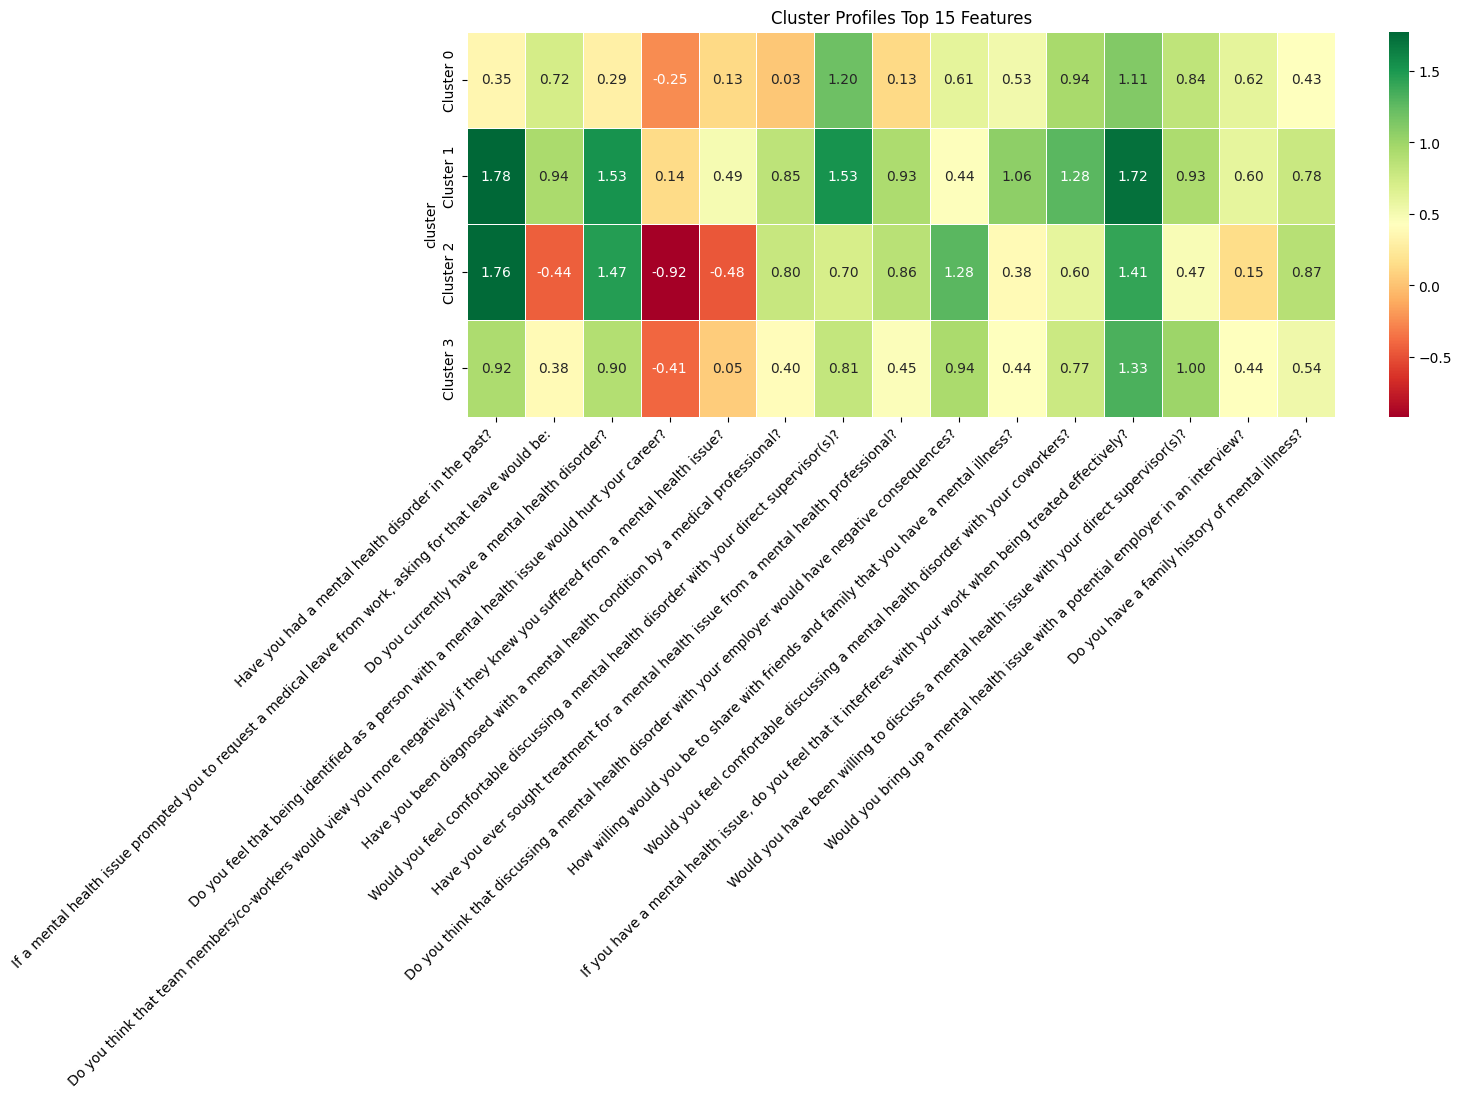

In [ ]:
# Excluding previous employer-related and age-related features for clearer cluster interpretation

exclude_keywords = ['previous', 'Previous', 'age', 'Age']
relevant_cols = [col for col in cluster_profiles.columns 
                 if not any(kw in col for kw in exclude_keywords)]

# Selecting the 15 features with the greates variance among the relevant columns

feature_variance_relevant = cluster_profiles[relevant_cols].var(axis=0)
top_features_relevant = feature_variance_relevant.nlargest(15).index

# Visualizing the most relevant features

plt.figure(figsize=(14, 5))
sns.heatmap(
    cluster_profiles[top_features_relevant].astype(float),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    yticklabels=[f'Cluster {i}' for i in range(best_k)]
)
plt.title('Cluster Profiles Top 15 Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The refined heatmap shows clearer differences between the clusters and will be used as the basis for cluster interpretation in the next steps.

In [78]:
for i, col in enumerate(top_features_relevant):
    print(f"\n{i}: {col}")
    print(df_employees[col].value_counts().sort_index())


0: Have you had a mental health disorder in the past?
Have you had a mental health disorder in the past?
0    379
1    184
2    583
Name: count, dtype: Int64

1: If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
-2    118
-1    199
0     178
1     431
2     220
Name: count, dtype: Int64

2: Do you currently have a mental health disorder?
Do you currently have a mental health disorder?
0    441
1    254
2    451
Name: count, dtype: Int64

3: Do you feel that being identified as a person with a mental health issue would hurt your career?
Do you feel that being identified as a person with a mental health issue would hurt your career?
-2     81
-1    447
0     472
1     121
2      25
Name: count, dtype: Int64

4: Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental h

In [ ]:
 # Checking encoding mappings for ordinal custom columns
 
for col in top_features_relevant:
    if col in custom_ordinal_columns:
        print(f"\n{col}")
        for original, encoded in custom_ordinal_columns[col].items():
            print(f"  '{original}' → {encoded}")


If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
  'Very difficult' → -2
  'Somewhat difficult' → -1
  'Neither easy nor difficult' → 0
  'Somewhat easy' → 1
  'Very easy' → 2

Do you feel that being identified as a person with a mental health issue would hurt your career?
  'Yes, it has' → -2
  'Yes, I think it would' → -1
  'Maybe' → 0
  'No, I don't think it would' → 1
  'No, it has not' → 2

Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?
  'Yes, they do' → -2
  'Yes, I think they would' → -1
  'Maybe' → 0
  'No, I don't think they would' → 1
  'No, they do not' → 2

How willing would you be to share with friends and family that you have a mental illness?
  'Not open at all' → -2
  'Somewhat not open' → -1
  'Neutral' → 0
  'Somewhat open' → 1
  'Very open' → 2

If you have a mental health issue, do you feel that it interferes with your work whe

In [ ]:
# Checking original question in raw dataset

print(df['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'].value_counts())

Would you have been willing to discuss a mental health issue with your direct supervisor(s)?
Some of my previous employers           654
No, at none of my previous employers    416
I don't know                            101
Yes, at all of my previous employers     93
Name: count, dtype: int64


During the encoding analysis it became apparent that the answers of the column 'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?' refer to previous employers, which could also be indicated by the past tense phrasing. This was overlooked earlier and the column will therefore be excluded from the visualization.

In [81]:
exclude_cols = ['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?']

relevant_cols = [col for col in cluster_profiles.columns 
                 if not any(kw in col for kw in exclude_keywords)
                 and col not in exclude_cols]

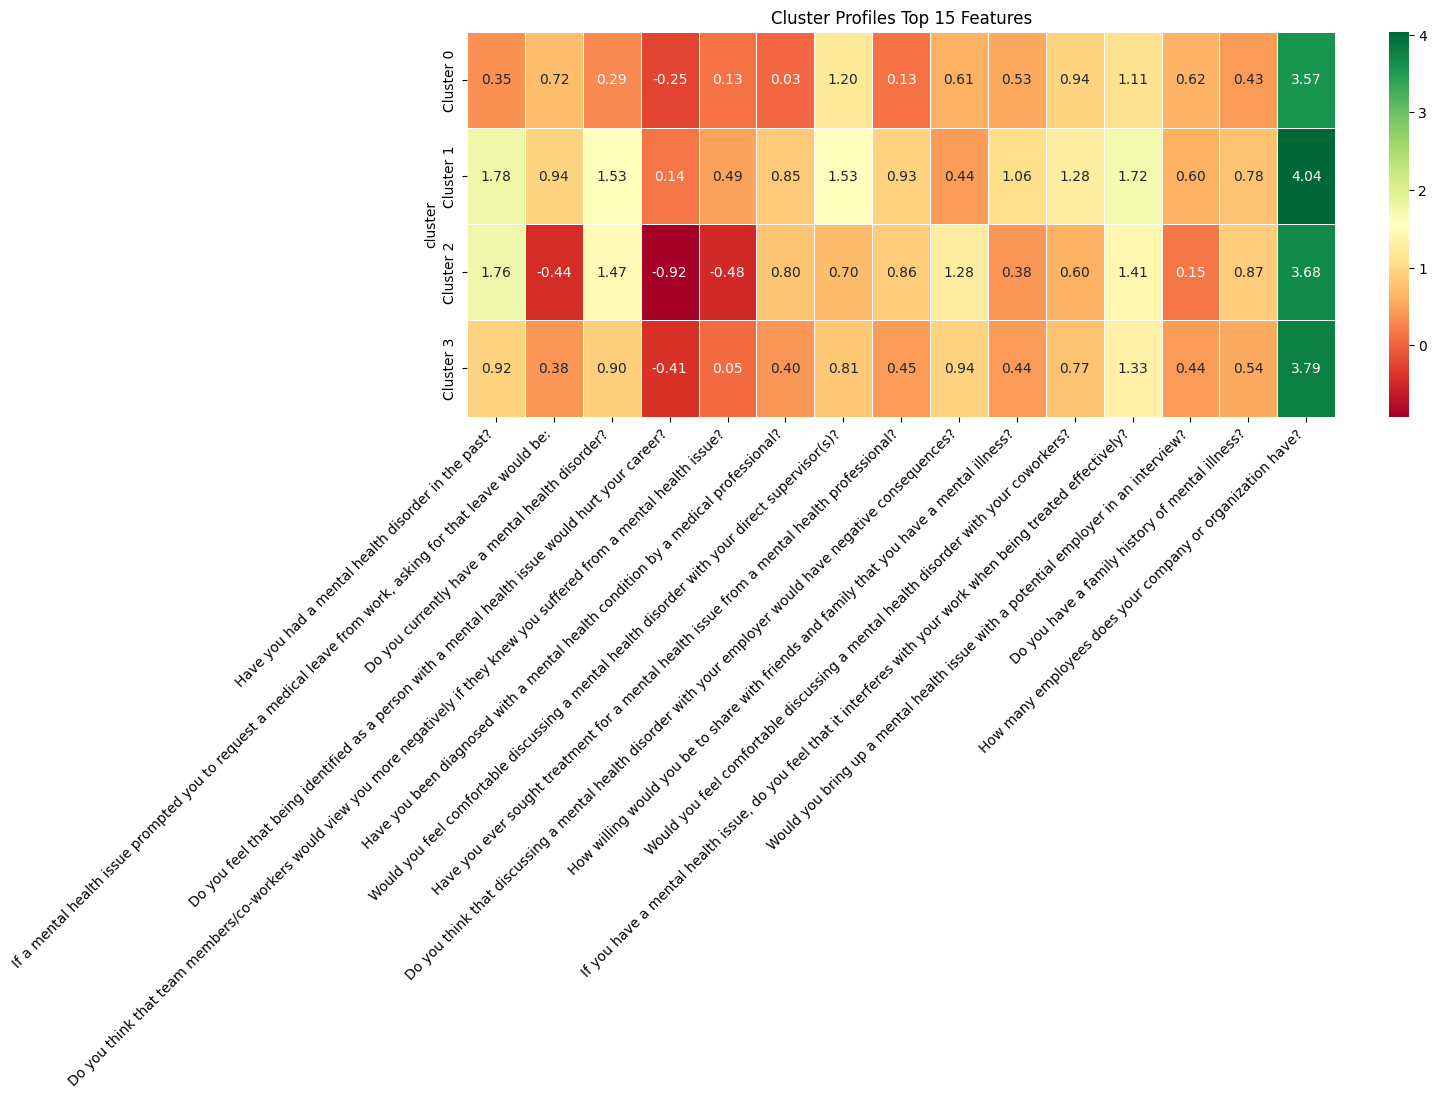

In [ ]:
# Recalculating top 15 features after excluding additional column

feature_variance_relevant = cluster_profiles[relevant_cols].var(axis=0)
top_features_relevant = feature_variance_relevant.nlargest(15).index

# New heatmap
plt.figure(figsize=(14, 5))
sns.heatmap(
    cluster_profiles[top_features_relevant].astype(float),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    yticklabels=[f'Cluster {i}' for i in range(best_k)]
)
plt.title('Cluster Profiles Top 15 Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The new heatmap shows a new dominant column in 'How many employees does your company or organization have?'. It has a larger value range (1-6) compared to all other features and will therefore also be excluded.

In [ ]:
# Excluding the column 'How many employees does your company or organization have?'

exclude_cols.append('How many employees does your company or organization have?')

relevant_cols = [col for col in cluster_profiles.columns 
                 if not any(kw in col for kw in exclude_keywords)
                 and col not in exclude_cols]

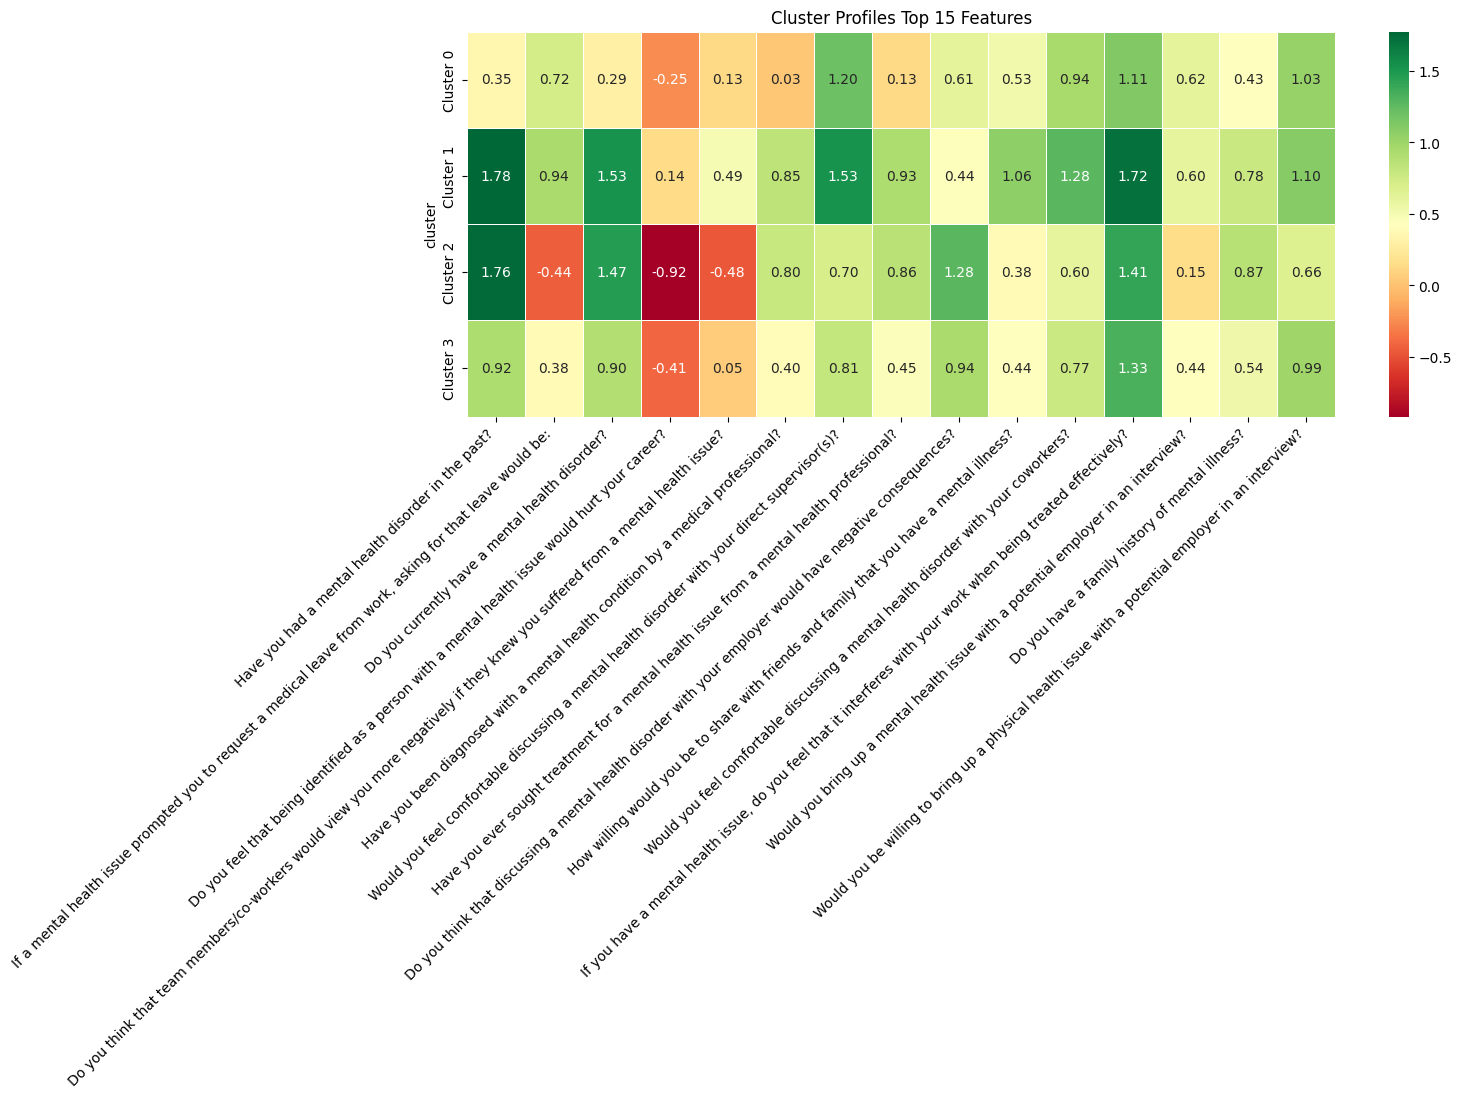

In [ ]:
# Recalculating top 15 features after excluding another additional column

feature_variance_relevant = cluster_profiles[relevant_cols].var(axis=0)
top_features_relevant = feature_variance_relevant.nlargest(15).index

# New heatmap

plt.figure(figsize=(14, 5))
sns.heatmap(
    cluster_profiles[top_features_relevant].astype(float),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    yticklabels=[f'Cluster {i}' for i in range(best_k)]
)
plt.title('Cluster Profiles Top 15 Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

After excluding additional columns, this heatmap now shows clear differences between the clusters without any dominant features distorting the color scale. Hence, this visualization will be used as the final basis for cluster interpretation in the next steps.

In [ ]:
# Checking value counts of top features to understand encoding direction

for i, col in enumerate(top_features_relevant):
    print(f"\n{i}: {col}")
    print(df_employees[col].value_counts().sort_index())


0: Have you had a mental health disorder in the past?
Have you had a mental health disorder in the past?
0    379
1    184
2    583
Name: count, dtype: Int64

1: If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
-2    118
-1    199
0     178
1     431
2     220
Name: count, dtype: Int64

2: Do you currently have a mental health disorder?
Do you currently have a mental health disorder?
0    441
1    254
2    451
Name: count, dtype: Int64

3: Do you feel that being identified as a person with a mental health issue would hurt your career?
Do you feel that being identified as a person with a mental health issue would hurt your career?
-2     81
-1    447
0     472
1     121
2      25
Name: count, dtype: Int64

4: Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental h

In [ ]:
# Checking encoding mappings for ordinal custom columns
 
for col in top_features_relevant:
    if col in custom_ordinal_columns:
        print(f"\n{col}")
        for original, encoded in custom_ordinal_columns[col].items():
            print(f"  '{original}' → {encoded}")


If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
  'Very difficult' → -2
  'Somewhat difficult' → -1
  'Neither easy nor difficult' → 0
  'Somewhat easy' → 1
  'Very easy' → 2

Do you feel that being identified as a person with a mental health issue would hurt your career?
  'Yes, it has' → -2
  'Yes, I think it would' → -1
  'Maybe' → 0
  'No, I don't think it would' → 1
  'No, it has not' → 2

Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?
  'Yes, they do' → -2
  'Yes, I think they would' → -1
  'Maybe' → 0
  'No, I don't think they would' → 1
  'No, they do not' → 2

How willing would you be to share with friends and family that you have a mental illness?
  'Not open at all' → -2
  'Somewhat not open' → -1
  'Neutral' → 0
  'Somewhat open' → 1
  'Very open' → 2

If you have a mental health issue, do you feel that it interferes with your work whe

After several iterations, the final heatmap excludes age, previous employer columns, company size and one additional column that was found to refer to previous employers in the answers. The encoding of all remaining features has been verified and the heatmap will now be used for cluster interpretation.

#### 7.3 Cluster Naming and Interpretation

In [ ]:
# Assigning descriptive names to the clusters

cluster_name_map = {
    0: 'Unaffected',
    1: 'Affected with High Trust',
    2: 'Affected with Low Trust',
    3: 'No Prior Experience'
}

df_employees['cluster_name'] = df_employees['cluster'].map(cluster_name_map)

# Checking name distribution after mapping

df_employees['cluster_name'].value_counts()

cluster_name
Unaffected                  399
Affected with Low Trust     348
Affected with High Trust    268
No Prior Experience         131
Name: count, dtype: int64

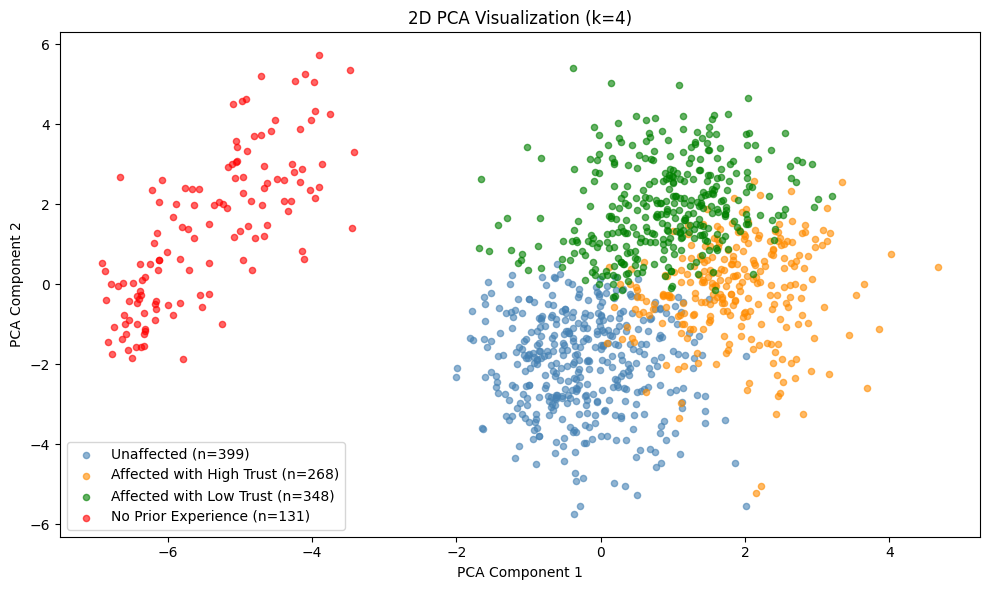

In [ ]:
# 2D PCA plot with cluster names

colors = ['steelblue', 'darkorange', 'green', 'red']

plt.figure(figsize=(10, 6))
for i, (cluster_num, name) in enumerate(cluster_name_map.items()):
    mask = cluster_labels == cluster_num
    plt.scatter(
        df_pca_2d[mask, 0],
        df_pca_2d[mask, 1],
        c=colors[i],
        label=f'{name} (n={mask.sum()})',
        alpha=0.6,
        s=20
    )

plt.title(f'2D PCA Visualization (k={best_k})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

The 2D visualization with cluster names confirms the four identified groups. No Prior Experience is clearly separated on the left, while the three remaining clusters overlap in the right area, which is expected as the 2D plot only 
captures a fraction of the total variance used for clustering.

#### 7.4 Clustering Summary

K-Means clustering with k=4 was applied to the PCA-reduced dataset of 1146 employees and 22 principal components. Although the Silhouette Score peaked at k=3 and k=5 (0.121), k=4 was selected as one cluster was expected to capture the structurally distinct group of participants without previous employer experience, leaving three meaningful clusters for the HR analysis.

That resulted in the clusters Unaffected (n=399), Affected with High Trust (n=268), Affected with Low Trust (n=348) and No Prior Experience (n=131). The heatmap analysis revealed clear differences between the clusters in terms of mental health prevalence, treatment-seeking behavior and openness towards discussing mental health in the workplace.